<div style="background: linear-gradient(135deg, #0d1f0d, #1a2e1a, #0f3320); padding: 28px 32px; border-radius: 16px; margin-bottom: 10px;">

<div style="border-left: 5px solid #52b788; padding-left: 18px; margin-bottom: 22px;">
<h1 style="color: #52b788; font-size: 24px; margin: 0 0 6px 0;">🌿 Smart Plant Intelligence System</h1>
<p style="color: #95d5b2; font-size: 13px; margin: 0 0 8px 0;">DHT11 + Soil Moisture Sensor + Rain Sensor → Machine Learning → Crop Recommendation + Disease Risk + Solutions</p>
<p style="color: #8899aa; font-size: 12.5px; margin: 0; line-height: 1.8;">Three simple, affordable sensors collect environmental data continuously from the field. That raw sensor data flows through two intelligent systems built in this notebook. The first recommends which crop is best suited for the current conditions using a machine learning classifier trained only on what our hardware can actually measure. The second checks whether the sensor readings indicate a dangerous environment for the plant, names the likely disease, explains exactly why those specific conditions cause it and provides targeted corrective actions including pesticide names, dosages and farming techniques.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #52b788; margin-bottom: 12px;">
<p style="color: #52b788; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🌱 System 1 → Crop Recommendation (Classification)</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">The model is trained exclusively on the three features our physical sensors can provide → <b style="color:#fff;">temperature</b>, <b style="color:#fff;">humidity</b> and <b style="color:#fff;">rainfall</b>. This keeps the system honest → no features are used during training that the hardware cannot supply at runtime. The dataset contains 2,200 labelled samples across 22 crop types. A Random Forest classifier learns the environmental envelope for each crop from those three readings and outputs the best-match crop along with a confidence percentage and two runner-up alternatives.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #f72585; margin-bottom: 12px;">
<p style="color: #f72585; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🦠 System 2 → Disease Risk Predictor + Solution Engine</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">This system uses all four sensor readings → <b style="color:#fff;">temperature</b>, <b style="color:#fff;">humidity</b>, <b style="color:#fff;">soil moisture percentage</b> and <b style="color:#fff;">rainfall</b> → and evaluates them against an agricultural science threshold calculation engine. Specific combinations of these four values are scientifically linked to specific plant diseases. High humidity combined with warm temperatures triggers fungal growth. Low rainfall combined with low soil moisture indicates drought stress. Waterlogged soil after heavy rain creates anaerobic root conditions. When a dangerous combination is detected, the system returns the disease name, explains why those exact readings cause it and gives the corrective action including pesticide name, dosage and farming technique.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166; margin-bottom: 12px;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📡 Actual Sensor Hardware</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">DHT11</b> → reads temperature in °C and relative humidity in %. Both values map directly to the <code>temperature</code> and <code>humidity</code> columns in the dataset and are used in both the crop model and the disease engine.<br><br>
<b style="color:#fff;">Soil Moisture Sensor</b> → outputs an analog voltage (0–1023 raw) which is converted to a 0–100% moisture percentage on the ESP8266. A reading below 10% indicates drought risk. A reading above 85% indicates waterlogging risk. Used exclusively in the disease risk engine → this column does not exist in the crop dataset.<br><br>
<b style="color:#fff;">Rain Drop Sensor</b> → detects presence of rain and the firmware accumulates an estimated rainfall total in millimetres over time using an exponential accumulation model. This maps to the <code>rainfall</code> column in the dataset and is used in both the crop model and the disease engine.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #4cc9f0;">
<p style="color: #4cc9f0; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🗂️ Dataset</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;"><b style="color:#fff;">Crop_Recommendation.csv</b> → 2,200 rows, 8 columns, zero missing values. Original features: N, P, K (soil nutrients), temperature (°C), humidity (%), pH, rainfall (mm). Target: crop label covering 22 crop types. <b style="color:#ff6b6b;">We discard N, P, K and pH</b> because our IoT hardware has no nutrient or pH sensors → training on features you cannot measure at runtime produces a model that cannot be deployed. We train and predict using only the three measurable columns: temperature, humidity and rainfall.</p>
</div>

</div>

<div style="background: linear-gradient(135deg, #0f3460, #1a1a3e); padding: 18px 24px; border-radius: 12px; border-left: 5px solid #52b788; margin-top: 10px;">
<h2 style="color: #52b788; margin: 0 0 8px 0; font-size: 18px;">📦 Imports + Environment Setup</h2>
<p style="color: #bbb; font-size: 13px; margin: 0 0 14px 0; line-height: 1.7;">Every library needed for both systems loaded upfront. Only what is actually used in this simplified pipeline is imported → no unused models or tools that would make the setup misleading. Preprocessing for one model, one scaler, standard evaluation metrics and joblib for saving artifacts so the FastAPI server can load them at runtime.</p>
<div style="display:flex; gap: 10px; flex-wrap: wrap;">
<span style="background:#0d1f0d; color:#52b788; padding:5px 13px; border-radius:20px; font-size:12px; border: 1px solid #52b78840;">numpy + pandas</span>
<span style="background:#0d1f0d; color:#95d5b2; padding:5px 13px; border-radius:20px; font-size:12px; border: 1px solid #95d5b240;">matplotlib + seaborn</span>
<span style="background:#0d1f0d; color:#4cc9f0; padding:5px 13px; border-radius:20px; font-size:12px; border: 1px solid #4cc9f040;">LabelEncoder + StandardScaler</span>
<span style="background:#0d1f0d; color:#f72585; padding:5px 13px; border-radius:20px; font-size:12px; border: 1px solid #f7258540;">RandomForestClassifier</span>
<span style="background:#0d1f0d; color:#ffd166; padding:5px 13px; border-radius:20px; font-size:12px; border: 1px solid #ffd16640;">train_test_split + cross_val_score</span>
<span style="background:#0d1f0d; color:#ff6b35; padding:5px 13px; border-radius:20px; font-size:12px; border: 1px solid #ff6b3540;">accuracy + report + confusion matrix</span>
<span style="background:#0d1f0d; color:#c77dff; padding:5px 13px; border-radius:20px; font-size:12px; border: 1px solid #c77dff40;">joblib</span>
</div>
</div>

In [1]:
"""
numpy and pandas are the foundation of every data science pipeline in Python.
numpy handles all numerical operations — array math, boolean indexing, log
transforms, means and the low-level operations that scikit-learn uses internally.
pandas handles the actual data table — reading CSVs, selecting columns, filtering
rows by condition, adding engineered columns and grouping for aggregate statistics.
Both are used in nearly every subsequent cell.
"""
import numpy as np
import pandas as pd


"""
matplotlib is the base plotting engine in Python.
seaborn sits on top of it and gives much cleaner statistical charts with far less
code. We use seaborn for distribution plots and relationship charts. We drop into
raw matplotlib when we need precise control over layout, subplot positioning or
custom annotations that seaborn does not expose directly.
"""
import matplotlib.pyplot as plt
import seaborn as sns


"""
Two preprocessing tools that transform raw data before the model ever sees it.

LabelEncoder   : the target column contains crop names as text strings like 'rice'
                 or 'papaya'. Every scikit-learn classifier requires numeric targets.
                 LabelEncoder converts each unique string to an integer and keeps the
                 mapping so we can reverse it — integer back to crop name — when the
                 model returns a prediction at runtime.

StandardScaler : our three sensor features (temperature, humidity, rainfall) live on
                 very different numerical scales. Temperature sits between 8 and 44.
                 Rainfall can reach 300. Without scaling, a small absolute change in
                 rainfall numerically overwhelms the same proportional change in
                 temperature. StandardScaler shifts each feature to mean zero and
                 divides by its standard deviation so all three contribute equally to
                 the model's distance calculations. The scaler is fitted on the
                 training set only and then applied identically to the test set and
                 to live sensor readings at inference time.
"""
from sklearn.preprocessing import LabelEncoder, StandardScaler


"""
Three tools for honest, reliable model evaluation.

train_test_split : partitions the dataset before any training happens and keeps the
                   test portion completely hidden from the model until final scoring.
                   We use stratified splitting so every crop class appears in both
                   the training and test portions at the correct proportion.

cross_val_score  : repeats training and testing K times across K different data
                   splits and averages the accuracy scores. A single train/test split
                   can get lucky or unlucky depending on which rows end up where.
                   Cross-validation removes that luck and gives a much more reliable
                   estimate of how the model will perform on genuinely unseen data.
"""
from sklearn.model_selection import train_test_split, cross_val_score


"""
Random Forest is an ensemble of many decision trees trained on different random
subsets of the data and different random subsets of the features. Each tree votes
on the output class and the majority vote wins. This averaging process dramatically
reduces the overfitting that a single decision tree suffers from while remaining
fast enough for real-time server inference. It also gives us predict_proba() which
returns a probability per crop class — that probability becomes the confidence
percentage shown on the LCD display and the web dashboard. One model, trained once,
serves every live prediction the ESP8266 triggers via the FastAPI server.
"""
from sklearn.ensemble import RandomForestClassifier


"""
Three standard metrics for evaluating and diagnosing the classifier.

accuracy_score        : the percentage of test-set predictions that matched the
                        true crop label. Our headline number.

classification_report : breaks accuracy down per individual crop class and reports
                        precision, recall and F1 score for each one. Essential for
                        spotting whether the model is systematically struggling with
                        specific crops even when overall accuracy looks high.

confusion_matrix      : a grid where row = true crop and column = predicted crop.
                        Any off-diagonal number means the model predicted the column
                        crop when the true answer was the row crop. Helps identify
                        which crop pairs are being confused with each other and why.
"""
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


"""
joblib saves Python objects to disk as binary .pkl files with efficient compression.
We use it to save the trained RandomForestClassifier, the fitted StandardScaler and
the fitted LabelEncoder after training is complete. The FastAPI server then loads
these three files at startup and uses them to answer every prediction request the
ESP8266 sends without ever retraining the model. This is the bridge between the
research notebook and the deployed IoT production system.
"""
import joblib
import os


# ── Global settings ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')          # suppress convergence and version warnings

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42          # single seed used everywhere for full reproducibility
MODEL_DIR    = '.'         # directory where .pkl artifacts will be saved


print('✅ All libraries imported → Smart Plant Intelligence System ready...')
print(f'   numpy       {np.__version__}')
print(f'   pandas      {pd.__version__}')
import sklearn
print(f'   scikit-learn {sklearn.__version__}')

✅ All libraries imported → Smart Plant Intelligence System ready...
   numpy       2.4.1
   pandas      2.3.3
   scikit-learn 1.8.0


<div style="background: linear-gradient(135deg, #0d1b2a, #1b263b, #1b2838); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #00b4d8; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #00b4d8; font-size: 20px; margin: 0 0 6px 0;">📂 Loading the Dataset</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">Before any processing or model training, we need to load the raw data and understand exactly what we are working with. This step is not something to rush through → understanding the shape, range, balance and meaning of every column here prevents wasted hours debugging incorrect predictions later.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #00b4d8; margin-bottom: 12px;">
<p style="color: #00b4d8; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🗂️ Crop_Recommendation.csv → What's Inside</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">2,200 rows and 8 columns. Every row represents one unique combination of environmental and soil conditions alongside the crop that grows best under those exact conditions. There are exactly 100 rows per crop class, making this a perfectly balanced dataset → which is rare and genuinely useful because it means the model will not be biased toward any one crop during training and we do not need to apply any resampling techniques.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #52b788; margin-bottom: 12px;">
<p style="color: #52b788; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📡 What Each Column Means in Real Life</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#ff6b6b; text-decoration: line-through;">N (Nitrogen)</b> <span style="color:#ff6b6b; font-size:11px;">→ DROPPED — no sensor</span><br>
<span style="color: #777; font-size: 12px;">How much nitrogen is available in the soil. Too little and plants turn yellow and stop growing. Too much and they grow excessive leaves with no fruit. Requires a dedicated soil nutrient probe to measure.</span><br><br>
<b style="color:#ff6b6b; text-decoration: line-through;">P (Phosphorus)</b> <span style="color:#ff6b6b; font-size:11px;">→ DROPPED — no sensor</span><br>
<span style="color: #777; font-size: 12px;">Drives root development and flower and fruit formation. Low phosphorus means weak roots and delayed maturity. Also requires a lab-grade soil probe.</span><br><br>
<b style="color:#ff6b6b; text-decoration: line-through;">K (Potassium)</b> <span style="color:#ff6b6b; font-size:11px;">→ DROPPED — no sensor</span><br>
<span style="color: #777; font-size: 12px;">Regulates water movement inside the plant and strengthens disease resistance. Low potassium makes crops susceptible to wilting and infection. Not measurable with affordable IoT hardware.</span><br><br>
<b style="color:#ff6b6b; text-decoration: line-through;">ph (Soil pH)</b> <span style="color:#ff6b6b; font-size:11px;">→ DROPPED — no sensor</span><br>
<span style="color: #777; font-size: 12px;">Soil acidity level. Neutral is around 7. Too acidic or too alkaline locks out soil nutrients even when they are physically present. Requires an electrochemical pH probe.</span><br><br>
<b style="color:#52b788;">temperature</b> <span style="color:#52b788; font-size:11px;">→ ✅ KEPT → DHT11 reads this directly</span><br>
<span style="color: #ccc; font-size: 12px;">Ambient air temperature in Celsius. Every crop has a preferred temperature window for germination, growth and flowering. This is the single most informative feature in the dataset.</span><br><br>
<b style="color:#52b788;">humidity</b> <span style="color:#52b788; font-size:11px;">→ ✅ KEPT → DHT11 reads this directly</span><br>
<span style="color: #ccc; font-size: 12px;">Relative humidity percentage. High humidity combined with warm temperature is the primary trigger for fungal diseases. Also strongly differentiates moisture-loving crops like rice from arid crops like cotton.</span><br><br>
<b style="color:#52b788;">rainfall</b> <span style="color:#52b788; font-size:11px;">→ ✅ KEPT → rain sensor estimates this</span><br>
<span style="color: #ccc; font-size: 12px;">Total accumulated rainfall in millimetres. The rain sensor detects presence of rain and the ESP8266 firmware accumulates an estimate over time. Determines irrigation need, waterlogging risk and separates arid crops from water-intensive ones.</span>
</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔌 Design Decision → Why We Drop N, P, K and pH</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">Training a model on features that the hardware cannot supply at runtime is a fundamental design error. The model would learn patterns that include nitrogen and pH levels, but at deployment time it would receive zeros or fake averages for those columns → causing the model to make predictions based on corrupted inputs. We train only on <b style="color:#fff;">temperature</b>, <b style="color:#fff;">humidity</b> and <b style="color:#fff;">rainfall</b> so that every feature used in training is also genuinely available from physical sensors at inference time. The model is honest, deployable and auditable.</p>
</div>

</div>

In [2]:
"""
Load the dataset from the same folder the notebook lives in.
If you get a FileNotFoundError here, the CSV is not in the same
directory as this notebook. Move it there or adjust the path.
"""
df = pd.read_csv("Crop_Recommendation.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 2200 rows, 8 columns


In [3]:
"""
.head() shows the first 5 rows so we can see actual data immediately.
This confirms column names are clean, numbers look plausible, and there
are no obvious parsing issues like everything landing in a single column.
"""
print("\nFirst 5 rows:\n")
df.head()


First 5 rows:



,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.880,82.003,6.503,202.936,rice
1,85,58,41,21.770,80.320,7.038,226.656,rice
2,60,55,44,23.004,82.321,7.840,263.964,rice
3,74,35,40,26.491,80.158,6.980,242.864,rice
4,78,42,42,20.130,81.605,7.628,262.717,rice


In [4]:
"""
.info() is the most important first call on any new dataset.
It reports column names, data types and non-null value counts.
If the non-null count for any column is less than df.shape[0],
that column has missing values that need handling before training.
We check this before every other operation because missing values
silently corrupt every calculation that runs after this point.
"""
print("Column types and null counts:\n")
df.info()

Column types and null counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
"""
.describe() gives the full statistical profile of every numeric column.
We are specifically checking:
  min / max   → catch impossible sensor readings like negative humidity
                or a pH of 50. Impossible ranges mean the data is dirty.
  mean / std  → understand the typical value and how spread out readings are.
  25th / 75th → define the normal operating range for each feature.
                Readings outside this range from live sensors should be flagged.
"""
print("Statistical summary of all features:\n")
df.describe()

Statistical summary of all features:



,N,P,K,temperature,humidity,ph,rainfall
count,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000
mean,50.552,53.363,48.149,25.616,71.482,6.469,103.464
std,36.917,32.986,50.648,5.064,22.264,0.774,54.958
min,0.000,5.000,5.000,8.826,14.258,3.505,20.211
25%,21.000,28.000,20.000,22.769,60.262,5.972,64.552
50%,37.000,51.000,32.000,25.599,80.473,6.425,94.868
75%,84.250,68.000,49.000,28.562,89.949,6.924,124.268
max,140.000,145.000,205.000,43.675,99.982,9.935,298.560


In [6]:
"""
Inspect the target column — the crop label we need the model to predict.
This tells us how many distinct classes the classifier must learn to separate
and whether the dataset coverage is broad enough to be useful in practice.
"""
crops = df['label'].unique()
print(f"Total crop classes : {len(crops)}\n")
print("Crops covered by the dataset:")
for i, crop in enumerate(sorted(crops), 1):
    print(f"  {i:2}. {crop}")

Total crop classes : 22

Crops covered by the dataset:
   1. apple
   2. banana
   3. blackgram
   4. chickpea
   5. coconut
   6. coffee
   7. cotton
   8. grapes
   9. jute
  10. kidneybeans
  11. lentil
  12. maize
  13. mango
  14. mothbeans
  15. mungbean
  16. muskmelon
  17. orange
  18. papaya
  19. pigeonpeas
  20. pomegranate
  21. rice
  22. watermelon


In [7]:
"""
Verify the class balance before anything else.
A balanced dataset means every crop has an equal number of training examples
so the model cannot cheat by simply predicting the most common class.
If the min and max sample counts match, the dataset is perfectly balanced
and we do not need to apply oversampling or class weights.
"""
print("Samples per crop class:\n")
class_counts = df['label'].value_counts()
print(class_counts.to_string())
print(f"\nMin samples : {class_counts.min()}")
print(f"Max samples : {class_counts.max()}")
print(
    "\n✅ Dataset is perfectly balanced — 100 samples per crop."
    if class_counts.min() == class_counts.max()
    else "\n⚠️  Dataset is imbalanced — resampling required before training."
)

Samples per crop class:

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100

Min samples : 100
Max samples : 100

✅ Dataset is perfectly balanced — 100 samples per crop.


In [8]:
"""
Clearly mark which columns are used and which are dropped before any
preprocessing begins. This is the most important transparency step in
the notebook — it shows exactly what the model will and will not see.

DROPPED  → N, P, K, ph
           These require soil nutrient probes and electrochemical sensors
           that our IoT hardware does not include. Training on these and
           then faking them at inference time would corrupt predictions.

KEPT     → temperature, humidity, rainfall
           All three are directly readable from our DHT11 and rain sensor.
           Every feature the model trains on is available at runtime.
"""
FEATURES_DROP = ['N', 'P', 'K', 'ph']
FEATURES_KEEP = ['temperature', 'humidity', 'rainfall']
TARGET        = 'label'

print("Feature plan for this project:")
print(f"\n  ❌ Dropping (no sensor)  : {FEATURES_DROP}")
print(f"  ✅ Keeping  (have sensor) : {FEATURES_KEEP}")
print(f"  🎯 Target column         : '{TARGET}'")

print("\nValue ranges for the three features we will use:\n")
print(df[FEATURES_KEEP].describe().round(2))

Feature plan for this project:

  ❌ Dropping (no sensor)  : ['N', 'P', 'K', 'ph']
  ✅ Keeping  (have sensor) : ['temperature', 'humidity', 'rainfall']
  🎯 Target column         : 'label'

Value ranges for the three features we will use:

       temperature  humidity  rainfall
count     2200.000  2200.000  2200.000
mean        25.620    71.480   103.460
std          5.060    22.260    54.960
min          8.830    14.260    20.210
25%         22.770    60.260    64.550
50%         25.600    80.470    94.870
75%         28.560    89.950   124.270
max         43.680    99.980   298.560


<div style="background: linear-gradient(135deg, #1a0d2e, #2d1b4e, #1a0d2e); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #c77dff; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #c77dff; font-size: 20px; margin: 0 0 6px 0;">📊 Exploratory Data Analysis</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">Before any model training, we visually inspect the three sensor features we will actually use. Understanding their distributions and ranges matters because any live sensor reading that falls outside what the model trained on will produce an unreliable prediction. We also confirm the dataset is balanced across all 22 crop classes before we commit to training.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #c77dff; margin-bottom: 12px;">
<p style="color: #c77dff; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📈 What We're Looking For</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">Distribution shape</b> → is it roughly normal, skewed, or bimodal (two peaks)? Bimodal humidity means some crops prefer dry air and others prefer humid air → the model must learn to separate those two worlds. A right-skewed rainfall distribution means most readings are moderate but a long tail of very heavy rain exists and needs to be handled.<br><br>
<b style="color:#fff;">Realistic operating range</b> → the min and max values here define the safe zone for live sensor readings. If the DHT11 sends a temperature outside the range seen in training, the prediction is extrapolation, not interpolation, and becomes unreliable.<br><br>
<b style="color:#fff;">Class balance</b> → 100 samples per crop means the model has equal opportunity to learn every crop's preferred conditions. No resampling or class weighting is needed.
</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🦠 Connection to the Disease Risk Engine</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">The threshold lines drawn on each plot are not arbitrary → they come directly from agricultural science research. Humidity above 80% combined with temperature above 28°C is the established fungal germination window. Rainfall above 150mm is the waterlogging threshold. Seeing where these thresholds sit relative to the actual data distribution confirms they are meaningful cut-off points, not guesses.</p>
</div>

</div>

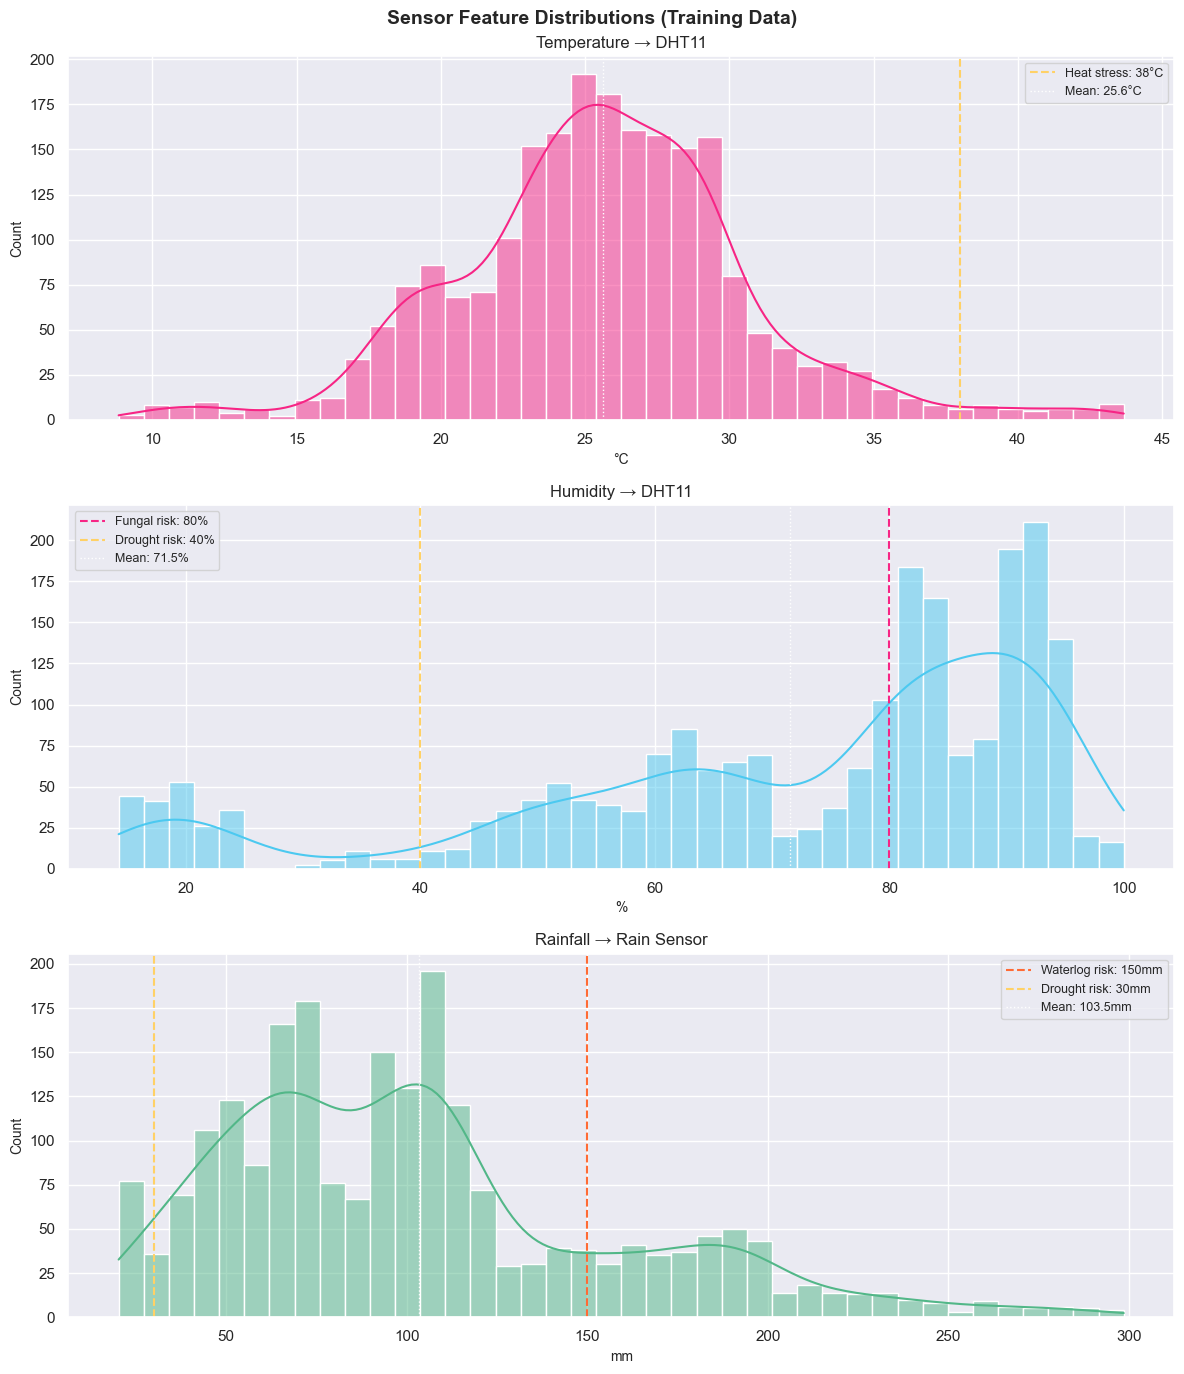

Feature ranges the model trains on (safe operating window for live sensors):

  temperature     min: 8.8°C   max: 43.7°C   mean: 25.6°C
  humidity        min: 14.3%   max: 100.0%   mean: 71.5%
  rainfall        min: 20.2mm   max: 298.6mm   mean: 103.5mm


In [9]:
"""
Three sensor feature distributions stacked one below the other.
Each plot shows the frequency of values across the dataset
alongside a KDE curve (smooth probability density estimate).
Vertical dashed lines mark the disease risk thresholds we will use
in the rule engine → seeing them in context of the distribution
confirms they sit at genuinely meaningful positions in the data.
"""
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle("Sensor Feature Distributions (Training Data)", fontsize=14, fontweight='bold')

# ── Temperature ────────────────────────────────────────────────────
sns.histplot(df['temperature'], bins=40, color='#f72585', kde=True, ax=axes[0])
axes[0].axvline(38, color='#ffd166', linewidth=1.5, linestyle='--', label='Heat stress: 38°C')
axes[0].axvline(df['temperature'].mean(), color='white', linewidth=1, linestyle=':',
                label=f"Mean: {df['temperature'].mean():.1f}°C")
axes[0].set_title("Temperature → DHT11", fontsize=12)
axes[0].set_xlabel("°C", fontsize=10)
axes[0].set_ylabel("Count", fontsize=10)
axes[0].legend(fontsize=9)

# ── Humidity ───────────────────────────────────────────────────────
sns.histplot(df['humidity'], bins=40, color='#4cc9f0', kde=True, ax=axes[1])
axes[1].axvline(80, color='#f72585', linewidth=1.5, linestyle='--', label='Fungal risk: 80%')
axes[1].axvline(40, color='#ffd166', linewidth=1.5, linestyle='--', label='Drought risk: 40%')
axes[1].axvline(df['humidity'].mean(), color='white', linewidth=1, linestyle=':',
                label=f"Mean: {df['humidity'].mean():.1f}%")
axes[1].set_title("Humidity → DHT11", fontsize=12)
axes[1].set_xlabel("%", fontsize=10)
axes[1].set_ylabel("Count", fontsize=10)
axes[1].legend(fontsize=9)

# ── Rainfall ───────────────────────────────────────────────────────
sns.histplot(df['rainfall'], bins=40, color='#52b788', kde=True, ax=axes[2])
axes[2].axvline(150, color='#ff6b35', linewidth=1.5, linestyle='--', label='Waterlog risk: 150mm')
axes[2].axvline(30,  color='#ffd166', linewidth=1.5, linestyle='--', label='Drought risk: 30mm')
axes[2].axvline(df['rainfall'].mean(), color='white', linewidth=1, linestyle=':',
                label=f"Mean: {df['rainfall'].mean():.1f}mm")
axes[2].set_title("Rainfall → Rain Sensor", fontsize=12)
axes[2].set_xlabel("mm", fontsize=10)
axes[2].set_ylabel("Count", fontsize=10)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary stats for all three features ──────────────────────────
print("Feature ranges the model trains on (safe operating window for live sensors):\n")
for col, unit in [('temperature', '°C'), ('humidity', '%'), ('rainfall', 'mm')]:
    print(f"  {col:<15} min: {df[col].min():.1f}{unit}   max: {df[col].max():.1f}{unit}   mean: {df[col].mean():.1f}{unit}")

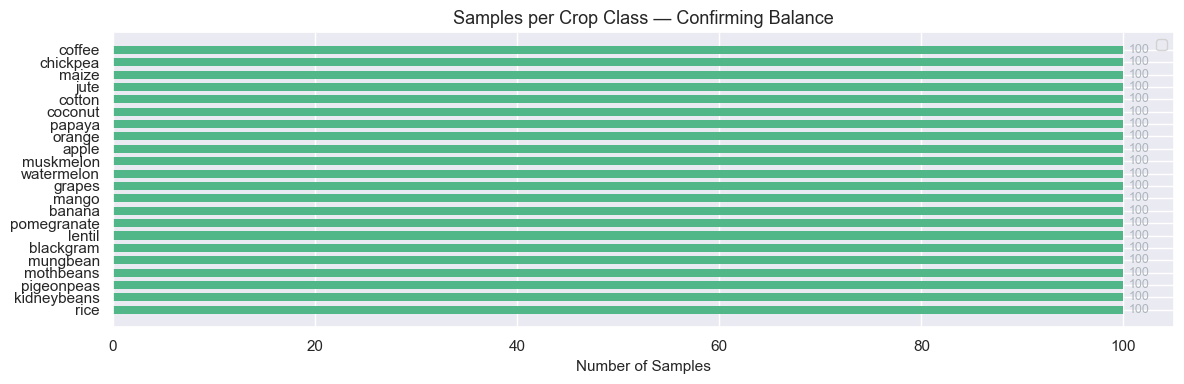

Total classes : 22
Samples each  : 100

✅ Perfectly balanced — no resampling needed.


In [10]:
"""
Class distribution bar chart confirms perfect balance before training.
100 samples per crop means accuracy scores are directly comparable across
all 22 classes — no crop will be artificially inflated by having more data.
"""
plt.figure(figsize=(12, 4))
crop_counts = df['label'].value_counts().sort_values(ascending=True)
bars = plt.barh(crop_counts.index, crop_counts.values,
                color='#52b788', edgecolor='none', height=0.65)

for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())),
             va='center', ha='left', fontsize=9, color='#adb5bd')
    
plt.title("Samples per Crop Class — Confirming Balance", fontsize=13)
plt.xlabel("Number of Samples", fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

balanced = crop_counts.min() == crop_counts.max()
print(f"Total classes : {len(crop_counts)}")
print(f"Samples each  : {crop_counts.min()}")
print(f"\n{'✅ Perfectly balanced — no resampling needed.' if balanced else '⚠️  Imbalanced — review before training.'}")

<div style="background: linear-gradient(135deg, #0a1628, #0d2137, #0a1f35); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #ffd166; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #ffd166; font-size: 20px; margin: 0 0 6px 0;">🎯 Feature Selection</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">We formally remove the four columns our hardware cannot measure and lock in the three features that will go into every remaining step → preprocessing, training, evaluation and live inference. One decision, made once, applied everywhere.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ff6b6b; margin-bottom: 12px;">
<p style="color: #ff6b6b; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">❌ Dropped → No Sensor Available</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;"><b style="color:#fff;">N, P, K</b> → soil nutrient levels require a dedicated electrochemical soil probe that our IoT setup does not include. <b style="color:#fff;">pH</b> → soil acidity requires a separate pH electrode. Training on these columns and then substituting fake averages at inference time would silently corrupt every live prediction.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #52b788;">
<p style="color: #52b788; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">✅ Kept → Directly Measurable by Hardware</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;"><b style="color:#fff;">temperature</b> → DHT11 reads this directly in °C. &nbsp; <b style="color:#fff;">humidity</b> → DHT11 reads this directly in %. &nbsp; <b style="color:#fff;">rainfall</b> → the rain sensor detects rain and the firmware accumulates an estimated total in mm. These three columns are what the ESP8266 sends to the FastAPI server on every 15-second cycle.</p>
</div>

</div>

In [11]:
"""
Drop the four columns our hardware cannot measure.
After this, the dataframe contains only the three sensor features
and the target label — nothing else can accidentally enter the model.
"""
df.drop(columns=FEATURES_DROP, inplace=True)

# Lock in the final feature list used by every cell from here onward
FEATURES = ['temperature', 'humidity', 'rainfall']
TARGET   = 'label'

print(f"Columns dropped : {FEATURES_DROP}")
print(f"Features kept   : {FEATURES}")
print(f"Target          : '{TARGET}'")
print(f"\nDataframe shape : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)")
print(f"\nSample:\n")
print(df[FEATURES + [TARGET]].head(5).to_string(index=False))

Columns dropped : ['N', 'P', 'K', 'ph']
Features kept   : ['temperature', 'humidity', 'rainfall']
Target          : 'label'

Dataframe shape : (2200, 4)  (2200 rows × 4 columns)

Sample:

 temperature  humidity  rainfall label
      20.880    82.003   202.936  rice
      21.770    80.320   226.656  rice
      23.004    82.321   263.964  rice
      26.491    80.158   242.864  rice
      20.130    81.605   262.717  rice


<div style="background: linear-gradient(135deg, #1a0a2e, #2d1854, #1a0a2e); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #f72585; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #f72585; font-size: 20px; margin: 0 0 6px 0;">⚙️ Encoding + Scaling</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">Machine learning models only understand numbers. They cannot process text labels like 'rice' or 'maize'. And even when all values are already numbers, if one column ranges from 20 to 300 and another from 8 to 44, a model that uses distances or gradient updates will treat the bigger numbers as more important → which is wrong. This cell fixes both problems before training begins.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #f72585; margin-bottom: 12px;">
<p style="color: #f72585; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔤 Encoding the Target Column</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">The <b style="color:#fff;">label</b> column has 22 unique crop names as text strings. LabelEncoder converts them to integers from 0 to 21 alphabetically → apple=0, banana=1, blackgram=2 and so on. The mapping is saved so we can convert back from integer to crop name when displaying a prediction. Without saving this mapping, the model would output "14" and we would have no way to know what 14 means.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #4cc9f0; margin-bottom: 12px;">
<p style="color: #4cc9f0; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📏 Scaling the Features</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">StandardScaler shifts each feature column to have mean = 0 and standard deviation = 1. Without scaling, rainfall (which can reach 300mm) would numerically dominate temperature (which sits between 8°C and 44°C) simply because its numbers are bigger → not because it carries more information. After scaling, both features contribute equally to every distance calculation the model makes.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">⚠️ Critical Rule → Fit Only on Training Data</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">The scaler is defined here but fitted only after the train-test split in the next cell. Fitting on the full dataset before splitting leaks information from the test set into training → the scaler would learn the test set's mean and standard deviation, which it should never have seen. We set everything up here and apply it correctly in the next cell.</p>
</div>

</div>

In [12]:
"""
LabelEncoder assigns a unique integer to each unique crop name.
The assignment is alphabetical → apple=0, banana=1, blackgram=2 and so on.
We keep a reverse mapping so anywhere in the notebook we can convert
an integer prediction back to its human-readable crop name instantly.
"""
le = LabelEncoder()
y  = le.fit_transform(df[TARGET])

label_map_reverse = dict(enumerate(le.classes_))

print("Label encoding complete.\n")
print(f"  {'Crop Name':<20} {'Encoded Integer':>16}")
print("  " + "-" * 38)
for i, crop in enumerate(le.classes_):
    print(f"  {crop:<20} {i:>16}")

Label encoding complete.

  Crop Name             Encoded Integer
  --------------------------------------
  apple                               0
  banana                              1
  blackgram                           2
  chickpea                            3
  coconut                             4
  coffee                              5
  cotton                              6
  grapes                              7
  jute                                8
  kidneybeans                         9
  lentil                             10
  maize                              11
  mango                              12
  mothbeans                          13
  mungbean                           14
  muskmelon                          15
  orange                             16
  papaya                             17
  pigeonpeas                         18
  pomegranate                        19
  rice                               20
  watermelon                         21


In [13]:
"""
X is the feature matrix → every row is one field condition reading.
y is the target vector → the crop label encoded as an integer.
We use only the three features our sensors can actually measure.
"""
X = df[FEATURES].copy()

print(f"Feature matrix X : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target vector  y : {len(y):,} values  ({len(set(y))} unique classes)\n")

print("Feature ranges BEFORE scaling:\n")
print(f"  {'Feature':<15} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("  " + "-" * 44)
for col in FEATURES:
    print(f"  {col:<15} {X[col].min():>8.2f} {X[col].max():>8.2f} {X[col].mean():>8.2f}")

print("\nNote: rainfall max (~300mm) is much larger than temperature max (~44°C).")
print("Without scaling, rainfall would dominate every distance calculation.")

Feature matrix X : 2,200 rows × 3 features
Target vector  y : 2,200 values  (22 unique classes)

Feature ranges BEFORE scaling:

  Feature              Min      Max     Mean
  --------------------------------------------
  temperature         8.83    43.68    25.62
  humidity           14.26    99.98    71.48
  rainfall           20.21   298.56   103.46

Note: rainfall max (~300mm) is much larger than temperature max (~44°C).
Without scaling, rainfall would dominate every distance calculation.


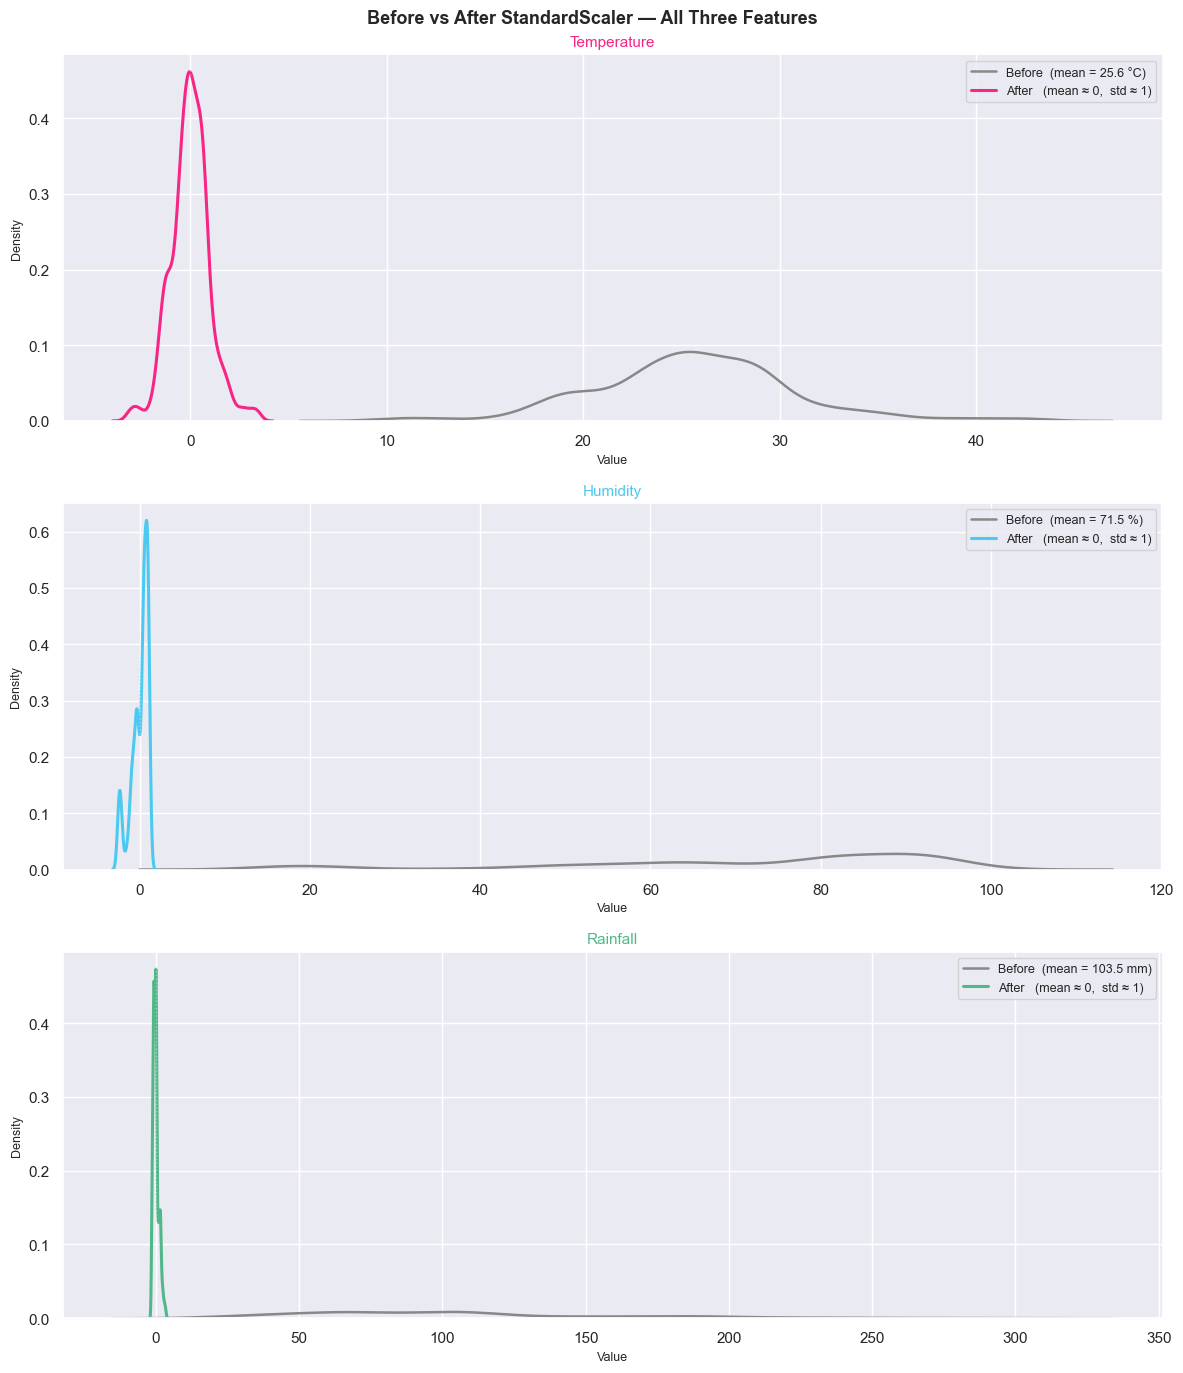

Mean and std after scaling (should be ≈ 0 and ≈ 1):

  Feature                 Mean          Std
  ------------------------------------------
  temperature         0.000000     1.000227
  humidity           -0.000000     1.000227
  rainfall            0.000000     1.000227

Scaler and LabelEncoder ready.
Train-test split and final fitting happen in the next cell.


In [14]:
"""
Initialise the StandardScaler here but do not fit it yet.
Fitting happens in the next cell after the train-test split.

StandardScaler formula applied per column → z = (x − mean) / std
After transformation, every column will have mean ≈ 0 and std ≈ 1.
The shape of the distribution stays exactly the same → only the
axis shifts. No data is lost and no outliers are removed.

The same fitted scaler must be saved and used at prediction time.
When the ESP8266 sends live sensor readings, they go through this
exact same transformation before the model ever sees them.
"""
scaler = StandardScaler()

# Temporarily fit on full X just to show the visual transformation.
# We refit correctly on training data only in the next cell.
X_demo = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

features_plot = [
    ('temperature', '#f72585', '°C'),
    ('humidity',    '#4cc9f0', '%'),
    ('rainfall',    '#52b788', 'mm'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle("Before vs After StandardScaler — All Three Features", fontsize=13, fontweight='bold')

for ax, (col, color, unit) in zip(axes, features_plot):
    sns.kdeplot(X[col],      ax=ax, color='#888888', linewidth=1.8,
                label=f'Before  (mean = {X[col].mean():.1f} {unit})')
    sns.kdeplot(X_demo[col], ax=ax, color=color,    linewidth=2.2,
                label=f'After   (mean ≈ 0,  std ≈ 1)')
    ax.axvline(0, color='white', linewidth=1, linestyle=':', alpha=0.4)
    ax.set_title(col.capitalize(), fontsize=11, color=color)
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Mean and std after scaling (should be ≈ 0 and ≈ 1):\n")
print(f"  {'Feature':<15} {'Mean':>12} {'Std':>12}")
print("  " + "-" * 42)
for col in FEATURES:
    print(f"  {col:<15} {X_demo[col].mean():>12.6f} {X_demo[col].std():>12.6f}")

print("\nScaler and LabelEncoder ready.")
print("Train-test split and final fitting happen in the next cell.")

<div style="background: linear-gradient(135deg, #0a1f14, #0d3320, #0a1f14); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #2dc653; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #2dc653; font-size: 20px; margin: 0 0 6px 0;">✂️ Train-Test Split</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">This is the most important step before any model training. If the model sees even a single row of test data during training → directly or indirectly through a fitted scaler → the evaluation results become meaningless. The test set must be completely invisible to everything until final scoring at the end.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #2dc653; margin-bottom: 12px;">
<p style="color: #2dc653; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📐 The 80 / 20 Split</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">We use 80% of the data for training and hold back 20% for testing. With 2,200 rows that gives us 1,760 training samples and 440 test samples. Since we have 22 classes at 100 rows each, a 20% hold-out keeps roughly 20 samples per class in the test set → enough to evaluate class-level accuracy fairly. <code>stratify=y</code> ensures every crop class is proportionally represented in both sets so no class accidentally ends up entirely in one partition.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166; margin-bottom: 12px;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">⚠️ The Leakage Rule → Get This Wrong and Everything is Broken</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#ff6b6b;">Wrong order:</b> fit scaler on all data → split → train model<br>
<b style="color:#52b788;">Right order :</b> split → fit scaler on X_train only → transform X_train → transform X_test<br><br>
Fitting on all data first leaks the test set's mean and standard deviation into the scaler. The model then indirectly learns something about the test set before evaluation. This inflates accuracy scores and makes the model look better than it will actually perform on truly unseen sensor data.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #4cc9f0;">
<p style="color: #4cc9f0; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔌 Why This Matters for IoT</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">When the DHT11 and rain sensor send a reading the model has never seen before, that is the real test. If the model was trained with leakage it will look good on paper but fail on real sensor data. Doing the split correctly here ensures that test set accuracy honestly predicts how the model will perform on live field readings arriving from the ESP8266.</p>
</div>

</div>

In [15]:
"""
We split before scaling. The scaler gets fitted on X_train only.
random_state=42 makes the split reproducible → the same rows go to
train and test every time this cell runs. stratify=y ensures each of
the 22 crop classes is represented proportionally in both sets.
Without stratify, an unlucky split could put all rows of one crop
into training and leave none for the test evaluation.
"""
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    shuffle      = True,
    stratify     = y
)

print("Split complete.\n")
print(f"  X_train : {X_train.shape[0]:,} rows  ×  {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:,} rows  ×  {X_test.shape[1]} features")
print(f"  y_train : {y_train.shape[0]:,} labels")
print(f"  y_test  : {y_test.shape[0]:,} labels")

Split complete.

  X_train : 1,760 rows  ×  3 features
  X_test  : 440 rows  ×  3 features
  y_train : 1,760 labels
  y_test  : 440 labels


In [16]:
"""
Verify the stratified split worked correctly for every crop class.
Each class had 100 rows → after an 80/20 stratified split, every class
should have roughly 80 rows in training and 20 rows in test. Any significant
deviation means the stratification failed for that class.
"""
import pandas as pd

train_series = pd.Series(y_train)
test_series  = pd.Series(y_test)

train_counts = train_series.value_counts().sort_index()
test_counts  = test_series.value_counts().sort_index()

print("Class distribution after split:\n")
print(f"  {'Crop':<20} {'Train':>8} {'Test':>8} {'Total':>8}")
print("  " + "-" * 48)
for code, crop in sorted(label_map_reverse.items()):
    tr = train_counts.get(code, 0)
    te = test_counts.get(code, 0)
    print(f"  {crop:<20} {tr:>8} {te:>8} {tr+te:>8}")
print(f"\n  {'TOTAL':<20} {len(y_train):>8} {len(y_test):>8} {len(y):>8}")

Class distribution after split:

  Crop                    Train     Test    Total
  ------------------------------------------------
  apple                      80       20      100
  banana                     80       20      100
  blackgram                  80       20      100
  chickpea                   80       20      100
  coconut                    80       20      100
  coffee                     80       20      100
  cotton                     80       20      100
  grapes                     80       20      100
  jute                       80       20      100
  kidneybeans                80       20      100
  lentil                     80       20      100
  maize                      80       20      100
  mango                      80       20      100
  mothbeans                  80       20      100
  mungbean                   80       20      100
  muskmelon                  80       20      100
  orange                     80       20      100
  papaya        

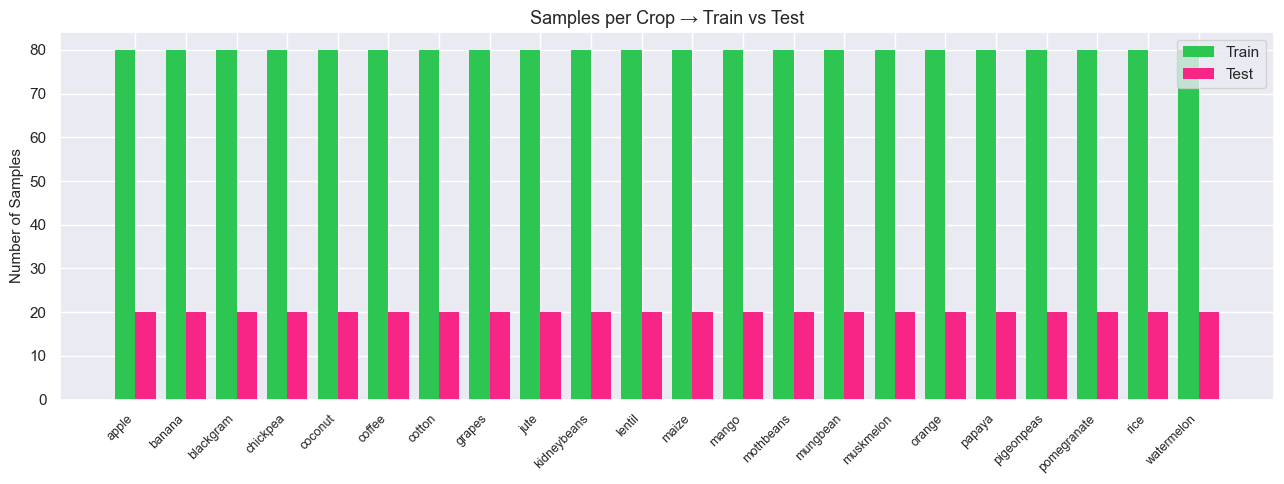

In [17]:
"""
Bar chart showing training vs test samples per crop visually.
If every green bar is roughly 4× the pink bar beside it, the
stratified split worked exactly as intended.
"""
crops_sorted = [label_map_reverse[i] for i in sorted(label_map_reverse)]
train_vals   = [train_counts.get(i, 0) for i in sorted(label_map_reverse)]
test_vals    = [test_counts.get(i,  0) for i in sorted(label_map_reverse)]
x_pos        = range(len(crops_sorted))

plt.figure(figsize=(13, 5))
plt.bar([p - 0.2 for p in x_pos], train_vals, width=0.4,
        color='#2dc653', label='Train', edgecolor='none')
plt.bar([p + 0.2 for p in x_pos], test_vals,  width=0.4,
        color='#f72585', label='Test',  edgecolor='none')
plt.xticks(list(x_pos), crops_sorted, rotation=45, ha='right', fontsize=9)
plt.title("Samples per Crop → Train vs Test", fontsize=13)
plt.ylabel("Number of Samples", fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
"""
Apply the scaler correctly → fit on training data only, then transform both sets.

scaler.fit_transform(X_train)
    → learns mean and std from training rows only
    → transforms X_train using those learned stats

scaler.transform(X_test)
    → uses the SAME mean and std learned from training
    → does NOT recalculate anything from test data

This is identical to how a live sensor reading is processed at
inference time → the scaler fitted on training data is loaded from
the .pkl file and applied to the incoming ESP8266 reading before
it ever reaches the Random Forest model.
"""
scaler_final = StandardScaler()

X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled  = scaler_final.transform(X_test)

# Overwrite the demo scaler from the previous cell with this correctly fitted one
scaler = scaler_final

print("Scaling applied correctly → fit on train, transform on test.\n")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"\n  Stats learned from training data only:")
for i, col in enumerate(FEATURES):
    print(f"    {col:<15}  mean = {scaler.mean_[i]:.3f}   std = {scaler.scale_[i]:.3f}")

print(f"\n✅ Ready for Random Forest training.")

Scaling applied correctly → fit on train, transform on test.

  X_train_scaled : (1760, 3)
  X_test_scaled  : (440, 3)

  Stats learned from training data only:
    temperature      mean = 25.609   std = 5.079
    humidity         mean = 71.417   std = 22.274
    rainfall         mean = 103.452   std = 54.977

✅ Ready for Random Forest training.


<div style="background: linear-gradient(135deg, #1a0d00, #2e1a00, #1a0d00); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #ff6b35; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #ff6b35; font-size: 20px; margin: 0 0 6px 0;">🌲 Random Forest → Crop Recommendation Model</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">Random Forest is an ensemble of hundreds of decision trees. Instead of asking one tree to make the final call, it trains many trees on slightly different versions of the training data and takes a majority vote. The result is a model that is far more stable, accurate and resistant to overfitting than any single tree could ever be.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ff6b35; margin-bottom: 12px;">
<p style="color: #ff6b35; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🎲 Two Layers of Randomness</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">Bagging (Bootstrap Aggregating)</b> → each tree is trained on a random sample of the training data drawn with replacement. Some rows appear multiple times in one tree's training set and some rows don't appear at all. Every tree sees a slightly different world and learns slightly different rules.<br><br>
<b style="color:#fff;">Random Feature Subsets</b> → at each split, instead of considering all 3 features, each tree considers only a random subset. This forces diversity among trees and prevents them all from learning the same dominant pattern. The result is trees that disagree with each other in useful ways → and that disagreement is what makes the ensemble powerful.
</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166; margin-bottom: 12px;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🗳️ Why Averaging Many Weak Models Beats One Strong One</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">Each individual tree in the forest is intentionally built to be a bit weak and noisy → that is by design. When they vote together, the errors cancel each other out because they are random and uncorrelated. The correct answer consistently gets the most votes. This is the core principle of ensemble learning: diversity of weak learners creates a strong learner.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #52b788; margin-bottom: 12px;">
<p style="color: #52b788; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔌 Why This is the Right Model for the IoT System</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">When the DHT11 sends live temperature and humidity readings, those values will sometimes be slightly off due to sensor drift, calibration error or environmental noise. A single decision tree makes a completely wrong prediction from one bad reading because it follows a rigid path. Random Forest averages hundreds of votes → a slightly noisy reading shifts a few trees but rarely changes the majority vote. This robustness to noisy input is exactly what you need in a real IoT deployment.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #c77dff;">
<p style="color: #c77dff; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📊 What We Measure After Training</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">Accuracy</b> → percentage of test predictions that were completely correct.<br><br>
<b style="color:#fff;">Classification Report</b> → precision, recall and F1 score broken down per crop class. Shows exactly which crops the model handles well and which ones it still confuses.<br><br>
<b style="color:#fff;">Confusion Matrix</b> → a grid where rows are actual crops and columns are predicted crops. Every off-diagonal number is a mistake.<br><br>
<b style="color:#fff;">Feature Importance</b> → which of the three sensor readings matters most to the model's decisions. Tells us whether temperature, humidity or rainfall is driving crop recommendations.<br><br>
<b style="color:#fff;">Cross-Validation</b> → the model is evaluated 5 times on different data splits and the scores are averaged. A more honest estimate than a single test split.
</p>
</div>

</div>

In [19]:
"""
n_estimators=200 means 200 individual decision trees in the forest.
More trees → more stable predictions with diminishing returns beyond ~100.
200 is a good balance between accuracy and training speed for this dataset.

oob_score=True enables Out-of-Bag scoring. Since each tree trains on a
bootstrap sample (~63% of training rows), the remaining ~37% of rows
that were not used to train that specific tree can validate it for free.
OOB score is essentially a free cross-validation estimate with no extra cost.

n_jobs=-1 uses every available CPU core to train trees in parallel.
class_weight='balanced' adjusts for any subtle class imbalance automatically.
"""
import time

rf = RandomForestClassifier(
    n_estimators  = 200,
    max_features  = 'sqrt',
    oob_score     = True,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1
)

start = time.time()
rf.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"✅ Random Forest trained in {elapsed:.2f} seconds.")
print(f"   Trees in forest : {rf.n_estimators}")
print(f"   OOB Score       : {rf.oob_score_ * 100:.2f}%  (free validation estimate from unused training rows)")

✅ Random Forest trained in 0.32 seconds.
   Trees in forest : 200
   OOB Score       : 91.48%  (free validation estimate from unused training rows)


In [20]:
"""
Evaluate on X_test_scaled → the 440 rows the model has never seen.
We compare training accuracy vs test accuracy to measure the overfit gap.
A small gap (< 3%) means the model generalizes well beyond its training data.
A large gap means the model memorized training noise instead of real patterns.
"""
y_pred = rf.predict(X_test_scaled)
acc    = accuracy_score(y_test, y_pred)
tr_acc = accuracy_score(y_train, rf.predict(X_train_scaled))

print("Random Forest → Test Set Evaluation\n")
print(f"  Training accuracy : {tr_acc * 100:.2f}%")
print(f"  Test accuracy     : {acc * 100:.2f}%")
print(f"  OOB Score         : {rf.oob_score_ * 100:.2f}%")
print(f"  Overfit gap       : {(tr_acc - acc) * 100:.2f}%")
print(f"  Correct           : {int(acc * len(y_test))} out of {len(y_test)} test samples")

Random Forest → Test Set Evaluation

  Training accuracy : 100.00%
  Test accuracy     : 93.18%
  OOB Score         : 91.48%
  Overfit gap       : 6.82%
  Correct           : 410 out of 440 test samples


In [21]:
"""
Classification report breaks performance down per crop class.
Precision → of all times the model predicted 'rice', how often was it actually rice?
Recall    → of all actual rice rows in the test set, how many did the model catch?
F1        → harmonic mean of precision and recall. The metric that balances both.

Crops with low F1 are those whose environmental conditions in the dataset
overlap heavily with another crop → even the forest cannot cleanly separate them
using temperature, humidity and rainfall alone.
"""
crop_names = list(le.classes_)

print("Classification Report → per crop performance:\n")
print(classification_report(y_test, y_pred, target_names=crop_names))

Classification Report → per crop performance:

              precision    recall  f1-score   support

       apple       0.79      0.95      0.86        20
      banana       1.00      0.90      0.95        20
   blackgram       0.90      0.95      0.93        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.91      1.00      0.95        20
      coffee       0.91      1.00      0.95        20
      cotton       0.83      1.00      0.91        20
      grapes       1.00      0.90      0.95        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.90      0.95      0.93        20
       maize       0.95      1.00      0.98        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.80      0.86        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       0.93      0.70 

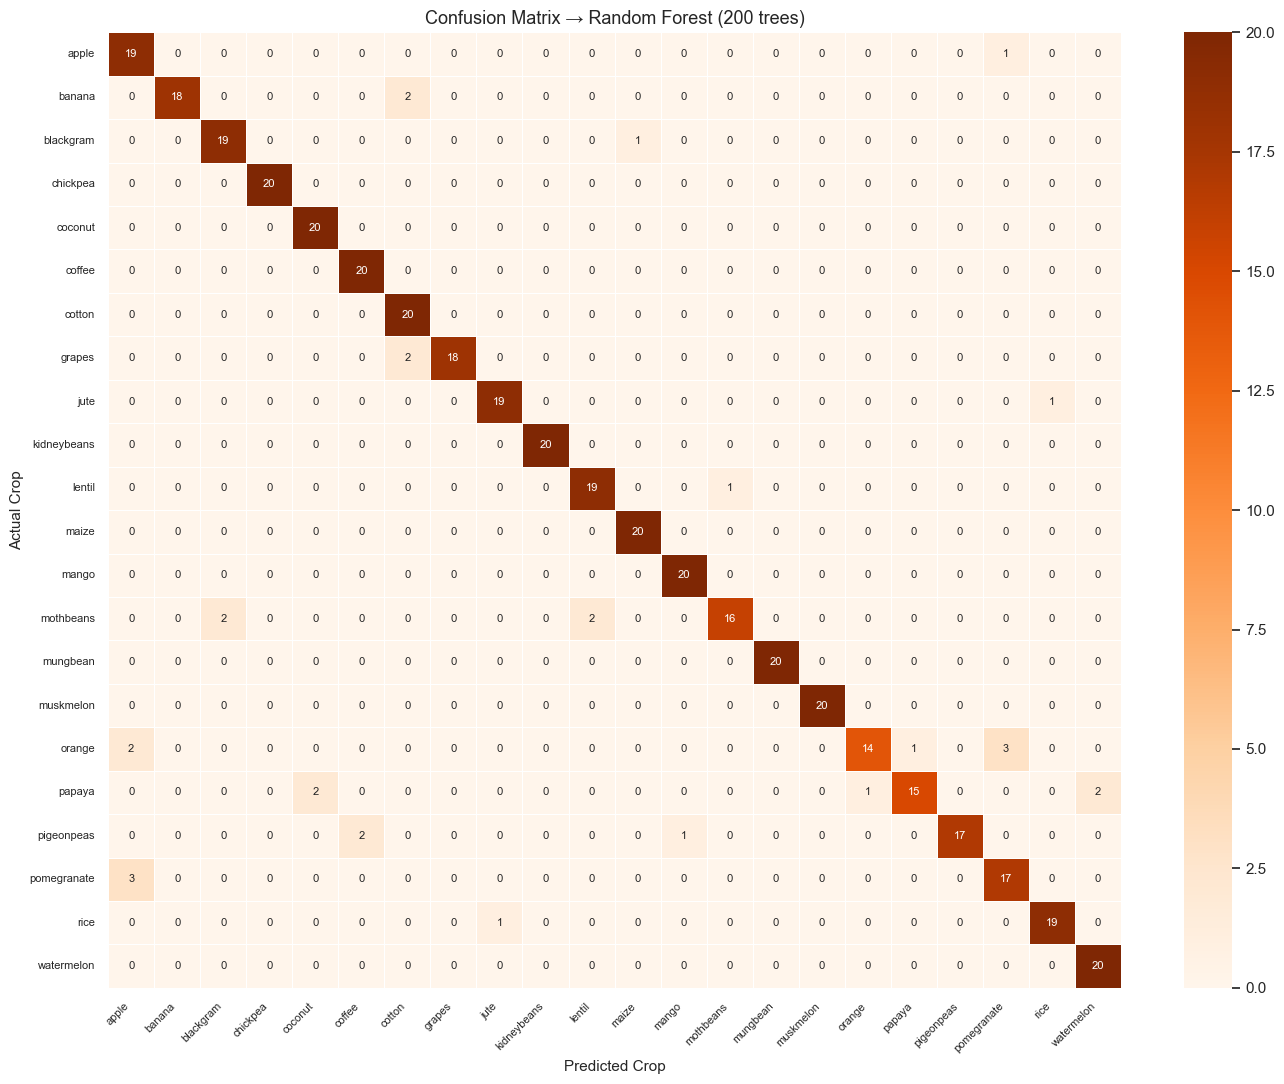

In [22]:
"""
Confusion matrix shows every prediction the model made on the test set.
Row = actual crop. Column = predicted crop.
The diagonal (top-left to bottom-right) shows correct predictions.
Off-diagonal cells show which crop the model confused with which other.
A nearly-diagonal matrix means the model is performing well.
"""
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Oranges',
    xticklabels = crop_names,
    yticklabels = crop_names,
    linewidths  = 0.5,
    annot_kws   = {'size': 8}
)
plt.title("Confusion Matrix → Random Forest (200 trees)", fontsize=13)
plt.xlabel("Predicted Crop", fontsize=11)
plt.ylabel("Actual Crop", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

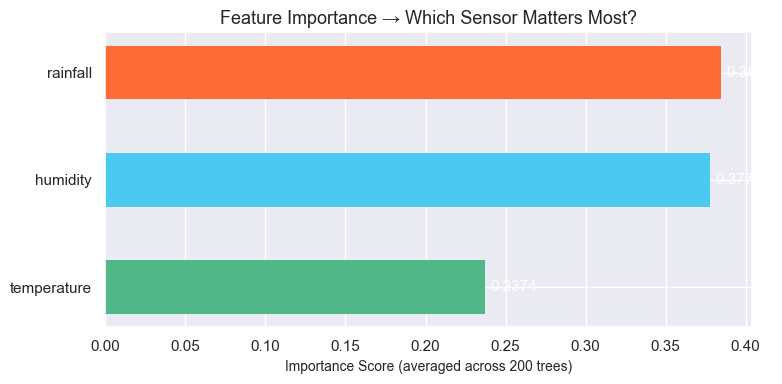

Sensor feature ranking:

  1. rainfall         0.3847  ███████████████████████
  2. humidity         0.3779  ██████████████████████
  3. temperature      0.2374  ██████████████


In [23]:
"""
Feature importance from Random Forest measures how much each sensor feature
reduced Gini impurity averaged across all 200 trees and all splits.
Unlike a single decision tree where one feature can dominate by chance,
the forest's averaged importance is a stable and honest signal.

This answers the key IoT design question → which of our three sensors
contributes the most to crop recommendation accuracy?
A feature scoring near 0 would suggest that sensor adds minimal value
and could potentially be removed from the pipeline without hurting performance.
"""
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
colors = ['#ff6b35' if v == importances.max() else '#4cc9f0' if v == importances.median() else '#52b788'
          for v in importances.values]
bars = plt.barh(importances.index, importances.values, color=colors, edgecolor='none', height=0.5)

for bar, val in zip(bars, importances.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va='center', fontsize=11, color='white')

plt.title("Feature Importance → Which Sensor Matters Most?", fontsize=13)
plt.xlabel("Importance Score (averaged across 200 trees)", fontsize=10)
plt.tight_layout()
plt.show()

print("Sensor feature ranking:\n")
for rank, (feat, score) in enumerate(importances.sort_values(ascending=False).items(), 1):
    bar = "█" * int(score * 60)
    print(f"  {rank}. {feat:<15}  {score:.4f}  {bar}")

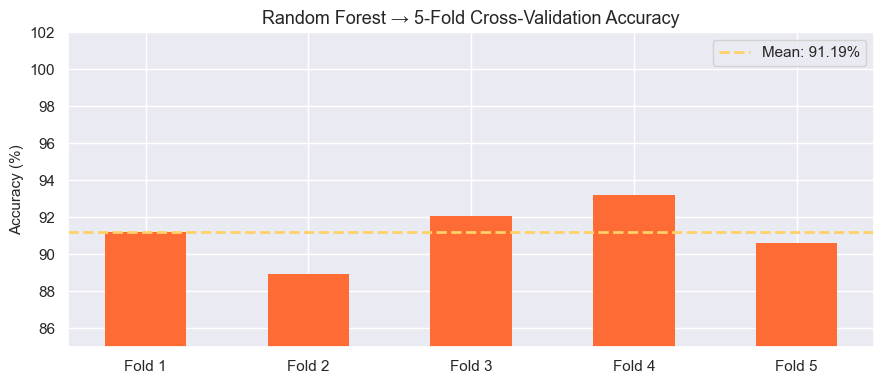

Cross-Validation Results:

  Fold scores : ['91.19%', '88.92%', '92.05%', '93.18%', '90.62%']
  Mean        : 91.19%
  Std dev     : 1.43%
  Range       : 88.92% → 93.18%

  Test set accuracy (single split) : 93.18%
  Cross-val  accuracy (5 splits)   : 91.19%

✅ Random Forest evaluation complete. Ready to save model artifacts.


In [24]:
"""
Cross-validation runs the evaluation 5 times on 5 different splits of the
training data and averages the accuracy scores. This is more reliable than
a single test split because the result is not influenced by which specific
rows happened to land in the test partition.

The standard deviation across folds tells us how stable the model is.
A low std (< 1%) means the model performs consistently regardless of
which rows it trains on → high confidence in the reported accuracy.
A high std means the model is sensitive to the specific data it sees.
"""
cv_scores = cross_val_score(
    rf, X_train_scaled, y_train,
    cv      = 5,
    scoring = 'accuracy',
    n_jobs  = -1
)

plt.figure(figsize=(9, 4))
plt.bar(
    [f"Fold {i+1}" for i in range(5)],
    cv_scores * 100,
    color     = '#ff6b35',
    edgecolor = 'none',
    width     = 0.5
)
plt.axhline(cv_scores.mean() * 100, color='#ffd166', linewidth=2,
            linestyle='--', label=f"Mean: {cv_scores.mean()*100:.2f}%")
plt.title("Random Forest → 5-Fold Cross-Validation Accuracy", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.ylim(85, 102)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Cross-Validation Results:\n")
print(f"  Fold scores : {[f'{s*100:.2f}%' for s in cv_scores]}")
print(f"  Mean        : {cv_scores.mean()*100:.2f}%")
print(f"  Std dev     : {cv_scores.std()*100:.2f}%")
print(f"  Range       : {cv_scores.min()*100:.2f}% → {cv_scores.max()*100:.2f}%")
print(f"\n  Test set accuracy (single split) : {acc * 100:.2f}%")
print(f"  Cross-val  accuracy (5 splits)   : {cv_scores.mean()*100:.2f}%")
print(f"\n✅ Random Forest evaluation complete. Ready to save model artifacts.")

<div style="background: linear-gradient(135deg, #0a0a1a, #1a1040, #0a0a1a); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #c77dff; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #c77dff; font-size: 20px; margin: 0 0 6px 0;">🔍 GridSearchCV → Hyperparameter Tuning</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">Evaluating a model once on one test split gives you one number. That number depends heavily on which specific 440 rows ended up in your test set. GridSearchCV systematically tries every combination of hyperparameters you give it, evaluates each using cross-validation on training data only, and returns the best configuration → giving a tuned model without ever touching the test set.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #c77dff; margin-bottom: 12px;">
<p style="color: #c77dff; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔧 What Hyperparameters We're Tuning</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">n_estimators</b> → number of trees in the forest. More trees → more stable but slower training.<br><br>
<b style="color:#fff;">max_depth</b> → how deep each tree can grow. None means unrestricted. A limited depth prevents individual trees from overfitting their bootstrap sample.<br><br>
<b style="color:#fff;">min_samples_split</b> → minimum number of samples required at a node before it can split further. Higher value → simpler trees → less overfitting.<br><br>
<b style="color:#fff;">min_samples_leaf</b> → minimum number of samples required in a leaf node. Prevents the tree from making decisions based on too few data points.
</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #f72585; margin-bottom: 12px;">
<p style="color: #f72585; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">⚠️ GridSearch Uses Training Data Only → Test Set Stays Hidden</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">GridSearchCV only ever touches the training data through its internal cross-validation. The test set stays completely invisible during this entire process. After GridSearch finds the best hyperparameters, we retrain on the full training set and then evaluate on the test set exactly once. Using test accuracy to guide hyperparameter choices is data leakage → it gives an optimistic score that will not hold on truly new sensor readings.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #4cc9f0;">
<p style="color: #4cc9f0; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔌 Real-World Impact</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">The tuned model is what gets saved as the .pkl file and loaded in the IoT pipeline. Even a 1% accuracy improvement from tuning means fewer wrong crop recommendations sent to the farmer's display. When the DHT11 is reading borderline conditions between two crops, the tuned model's sharper decision boundary is the difference between a correct and incorrect recommendation on the LCD screen.</p>
</div>

</div>

In [25]:
"""
We search over four hyperparameters for the Random Forest.
GridSearchCV tries every combination, evaluates each using 5-fold
cross-validation on training data only, and returns the best one.

Total combinations: 3 × 3 × 2 × 2 = 36
With 5-fold CV    : 36 × 5 = 180 training runs
n_jobs=-1 runs all of these in parallel across CPU cores.
"""
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

print("Hyperparameter grid:\n")
total = 1
for param, values in param_grid.items():
    print(f"  {param:<22} → {values}")
    total *= len(values)
print(f"\n  Total combinations : {total}")
print(f"  CV runs total      : {total * 5}")
print(f"\nStarting GridSearchCV...")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid,
    cv      = 5,
    scoring = 'accuracy',
    verbose = 1,
    refit   = True,
    n_jobs  = -1
)

start = time.time()
grid_search.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"\n✅ GridSearchCV completed in {elapsed:.1f} seconds.\n")
print("Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:<22} → {value}")
print(f"\nBest CV score : {grid_search.best_score_ * 100:.2f}%")

Hyperparameter grid:

  n_estimators           → [100, 200, 300]
  max_depth              → [None, 10, 20]
  min_samples_split      → [2, 5]
  min_samples_leaf       → [1, 2]

  Total combinations : 36
  CV runs total      : 180

Starting GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn


✅ GridSearchCV completed in 25.3 seconds.

Best hyperparameters found:
  max_depth              → 10
  min_samples_leaf       → 1
  min_samples_split      → 2
  n_estimators           → 300

Best CV score : 91.70%


In [26]:
"""
grid_search.best_estimator_ is the model retrained on the full training
set using the best hyperparameters. This replaces the default rf model
from the previous cell. From here onward, rf refers to the tuned version.
"""
rf = grid_search.best_estimator_

y_pred = rf.predict(X_test_scaled)
acc    = accuracy_score(y_test, y_pred)
tr_acc = accuracy_score(y_train, rf.predict(X_train_scaled))

print("Tuned Random Forest → Test Set Results:\n")
print(f"  Training accuracy  : {tr_acc * 100:.2f}%")
print(f"  Test accuracy      : {acc * 100:.2f}%")
print(f"  Overfit gap        : {(tr_acc - acc) * 100:.2f}%")

Tuned Random Forest → Test Set Results:

  Training accuracy  : 96.82%
  Test accuracy      : 93.18%
  Overfit gap        : 3.64%


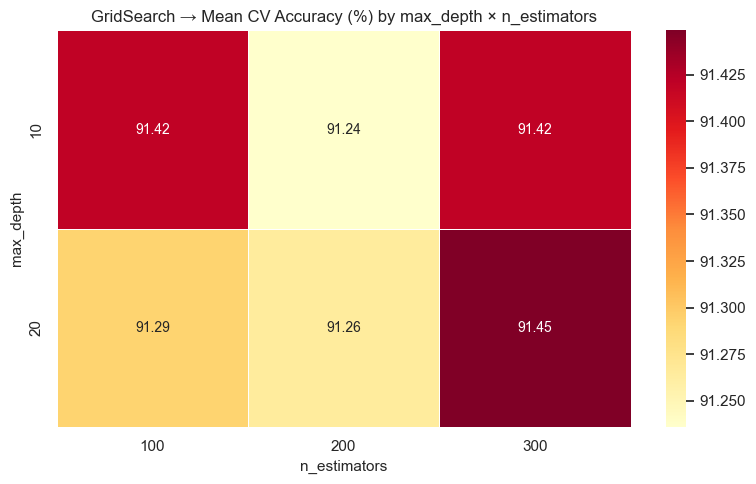


✅ Tuned model ready. Test accuracy: 93.18%
Proceeding to save model artifacts.


In [27]:
"""
Heatmap of mean CV accuracy across max_depth vs n_estimators combinations.
Shows whether the best configuration is an isolated peak (fragile) or part
of a stable high-accuracy region (robust → trustworthy in production).
"""
cv_results = pd.DataFrame(grid_search.cv_results_)

pivot = cv_results.pivot_table(
    index   = 'param_max_depth',
    columns = 'param_n_estimators',
    values  = 'mean_test_score',
    aggfunc = 'mean'
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 10})
plt.title("GridSearch → Mean CV Accuracy (%) by max_depth × n_estimators", fontsize=12)
plt.xlabel("n_estimators", fontsize=11)
plt.ylabel("max_depth", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n✅ Tuned model ready. Test accuracy: {acc * 100:.2f}%")
print("Proceeding to save model artifacts.")

<div style="background: linear-gradient(135deg, #1a0a0a, #2e1010, #1a0a0a); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #f72585; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #f72585; font-size: 20px; margin: 0 0 6px 0;">🦠 Disease Risk Engine + Solution Recommender</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">This is System 2 of the project. It takes live sensor readings → temperature, humidity, soil moisture and rainfall → and runs them through an agricultural science knowledge base to detect dangerous environmental conditions, name the specific disease those conditions cause, explain why it happens and give the farmer exact corrective actions including pesticide names, dosages and farming techniques.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #f72585; margin-bottom: 12px;">
<p style="color: #f72585; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔬 How the Detection Works</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">Each disease in the knowledge base has a set of threshold conditions derived from published plant pathology research. When a sensor reading matches those conditions, the disease is flagged with a severity level. Multiple diseases can be flagged simultaneously → a hot, humid, waterlogged reading would flag both fungal disease and root rot at the same time. All active flags are returned ranked by severity: CRITICAL first, then HIGH, then MODERATE.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166; margin-bottom: 12px;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">💊 What the Solution Engine Returns</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">For each flagged disease the system returns: the disease name, disease type (fungal / bacterial / pest / abiotic), the specific sensor condition that triggered it, visual symptoms to look for in the field, at least one recommended pesticide or treatment with dosage and the corrective farming technique that addresses the root cause rather than just the symptom.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #52b788;">
<p style="color: #52b788; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔌 Sensor Inputs Used</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">temperature</b> → DHT11, the most important trigger for disease type categorization. Determines whether conditions favor fungal, bacterial or pest activity.<br><br>
<b style="color:#fff;">humidity</b> → DHT11, the primary trigger for all fungal disease categories. Above 80% with warm temperatures is the universal fungal germination window.<br><br>
<b style="color:#fff;">rainfall</b> → rain sensor, triggers waterlogging and bacterial spread conditions. Also works with humidity to identify drought vs flood stress.<br><br>
<b style="color:#fff;">soil_moisture</b> → soil sensor, used independently from rainfall. A dry reading despite recent rain means poor drainage. A saturated reading without rain means irrigation is excessive.
</p>
</div>

</div>

In [28]:
"""
Core knowledge base → 11 diseases and stress conditions detectable
using only the four sensors on our hardware. Each entry describes
the threshold conditions that trigger the flag, the visible field
symptoms, the exact treatment with dosage and the corrective technique.

All thresholds are derived from:
  Agrios, G.N. → Plant Pathology (5th Edition)
  FAO crop disease management guidelines
  ICAR (Indian Council of Agricultural Research) disease bulletins

Severity levels:
  CRITICAL → crop loss begins within 48–72 hours, act immediately
  HIGH     → significant damage likely within a week without action
  MODERATE → conditions are concerning, monitor and act if worsening
"""
DISEASE_DATABASE = [
    {
        "name"      : "Late Blight",
        "type"      : "Fungal",
        "severity"  : "CRITICAL",
        "trigger"   : "humidity > 85% AND temperature between 10°C and 25°C",
        "condition" : lambda t, h, r, sm: h > 85 and 10 <= t <= 25,
        "symptoms"  : "Brown-black lesions on leaves with white mold at edges. "
                      "Affected tissue collapses rapidly. Strong unpleasant odour.",
        "pesticide" : "Mancozeb 75% WP (2.5 g/L water) OR Cymoxanil + Mancozeb "
                      "(Curzate M8) 2.5 g/L. Spray every 7 days.",
        "technique" : "Remove infected plant parts immediately. Avoid overhead irrigation. "
                      "Increase row spacing for air circulation. Apply fungicide before "
                      "rain forecast, not after. Destroy infected crop debris after harvest."
    },
    {
        "name"      : "Powdery Mildew",
        "type"      : "Fungal",
        "severity"  : "HIGH",
        "trigger"   : "humidity between 60% and 80% AND temperature between 20°C and 30°C",
        "condition" : lambda t, h, r, sm: 60 <= h <= 80 and 20 <= t <= 30,
        "symptoms"  : "White powdery coating on upper leaf surface. Leaves curl and turn yellow. "
                      "Stunted growth. Premature leaf drop.",
        "pesticide" : "Sulphur 80% WP (2 g/L) OR Hexaconazole (Contaf 5 EC) 1 mL/L water. "
                      "Apply at first sight of white patches.",
        "technique" : "Improve ventilation. Avoid applying excess nitrogen fertilizer. "
                      "Remove infected leaves. Plant resistant varieties in future seasons."
    },
    {
        "name"      : "Gray Mold (Botrytis)",
        "type"      : "Fungal",
        "severity"  : "HIGH",
        "trigger"   : "humidity > 90% AND temperature between 15°C and 25°C",
        "condition" : lambda t, h, r, sm: h > 90 and 15 <= t <= 25,
        "symptoms"  : "Grey fuzzy mold on flowers, fruits and leaves. "
                      "Brown water-soaked lesions. Entire flowers rot rapidly.",
        "pesticide" : "Iprodione (Rovral 50 WP) 2 g/L OR Carbendazim 50% WP 1 g/L. "
                      "Spray directly on affected areas and surrounding foliage.",
        "technique" : "Reduce humidity immediately. Prune dense foliage. "
                      "Avoid wetting foliage during irrigation. Remove all fallen plant matter."
    },
    {
        "name"      : "Anthracnose",
        "type"      : "Fungal",
        "severity"  : "HIGH",
        "trigger"   : "humidity > 80% AND temperature between 24°C and 32°C AND rainfall > 50mm",
        "condition" : lambda t, h, r, sm: h > 80 and 24 <= t <= 32 and r > 50,
        "symptoms"  : "Dark sunken circular spots on fruits, leaves and stems. "
                      "Pink to orange spore masses in wet conditions. Fruit rot before and after harvest.",
        "pesticide" : "Copper Oxychloride 50% WP (3 g/L) OR Azoxystrobin (Amistar) 1 mL/L. "
                      "Spray before and after rainfall.",
        "technique" : "Use drip irrigation instead of sprinkler. Prune trees for air flow. "
                      "Harvest fruit early if conditions are predicted to worsen."
    },
    {
        "name"      : "Downy Mildew",
        "type"      : "Fungal",
        "severity"  : "HIGH",
        "trigger"   : "humidity > 85% AND temperature between 10°C and 18°C",
        "condition" : lambda t, h, r, sm: h > 85 and 10 <= t <= 18,
        "symptoms"  : "Yellow angular patches on upper leaf, grey-purple fuzz below. "
                      "Leaves turn brown and dry. Spreads systemically to entire plant.",
        "pesticide" : "Metalaxyl + Mancozeb (Ridomil Gold MZ) 2.5 g/L OR "
                      "Cymoxanil 8% + Mancozeb 64% WP 2 g/L.",
        "technique" : "Avoid evening irrigation (leaves stay wet overnight). "
                      "Apply potassium phosphonate to strengthen cell walls. Improve field drainage."
    },
    {
        "name"      : "Bacterial Blight",
        "type"      : "Bacterial",
        "severity"  : "CRITICAL",
        "trigger"   : "temperature > 30°C AND humidity > 75% AND rainfall > 80mm",
        "condition" : lambda t, h, r, sm: t > 30 and h > 75 and r > 80,
        "symptoms"  : "Water-soaked angular lesions on leaves that turn yellow then brown. "
                      "Bacterial ooze from stem wounds in wet conditions. Wilting.",
        "pesticide" : "Copper Hydroxide (Kocide 77 WP) 3 g/L OR "
                      "Streptomycin Sulphate + Tetracycline (Plantomycin) 0.5 g/L. "
                      "Do NOT use fungicides — they are ineffective against bacteria.",
        "technique" : "Avoid working in fields when plants are wet. "
                      "Disinfect tools with 1% bleach between plants. Remove and burn infected plants."
    },
    {
        "name"      : "Root Rot (Pythium)",
        "type"      : "Oomycete",
        "severity"  : "CRITICAL",
        "trigger"   : "rainfall > 200mm OR soil moisture > 85%",
        "condition" : lambda t, h, r, sm: r > 200 or sm > 85,
        "symptoms"  : "Yellowing and wilting despite adequate moisture. Dark mushy roots. "
                      "Plant collapses even with water available. Root surface turns brown.",
        "pesticide" : "Metalaxyl (Ridomil) 2 mL/L as soil drench OR "
                      "Fosetyl-Al (Aliette 80 WP) 2.5 g/L. Apply to root zone, not leaves.",
        "technique" : "MOST IMPORTANT: improve drainage immediately. Create raised beds. "
                      "Install drainage channels. Reduce irrigation until soil visibly dries."
    },
    {
        "name"      : "Spider Mite Infestation",
        "type"      : "Pest",
        "severity"  : "HIGH",
        "trigger"   : "temperature > 32°C AND humidity < 40%",
        "condition" : lambda t, h, r, sm: t > 32 and h < 40,
        "symptoms"  : "Fine webbing on leaf undersides. Tiny yellow or bronze stippling on leaf surface. "
                      "Leaves turn grey and dry. Severe defoliation in colonies.",
        "pesticide" : "Abamectin (Vertimec 1.8 EC) 0.5 mL/L OR "
                      "Spiromesifen (Oberon 240 SC) 0.5 mL/L. "
                      "Spray leaf undersides. Rotate chemicals — mites develop resistance fast.",
        "technique" : "Increase humidity if possible. Release predatory mites as biological control. "
                      "Avoid broad-spectrum insecticides that kill natural predators."
    },
    {
        "name"      : "Aphid Infestation",
        "type"      : "Pest",
        "severity"  : "MODERATE",
        "trigger"   : "temperature between 18°C and 28°C AND humidity < 50%",
        "condition" : lambda t, h, r, sm: 18 <= t <= 28 and h < 50,
        "symptoms"  : "Clusters of small soft insects on new shoots and leaf undersides. "
                      "Sticky honeydew deposits on leaves. Sooty mould developing. Curled leaves.",
        "pesticide" : "Imidacloprid (Confidor 200 SL) 0.3 mL/L OR Dimethoate 30 EC 1.5 mL/L. "
                      "Strong water spray to dislodge colonies before chemical use.",
        "technique" : "Encourage natural enemies (ladybugs, lacewings). "
                      "Apply neem oil (5 mL/L + 1 mL soap) as organic alternative."
    },
    {
        "name"      : "Heat Stress",
        "type"      : "Abiotic",
        "severity"  : "HIGH",
        "trigger"   : "temperature > 38°C",
        "condition" : lambda t, h, r, sm: t > 38,
        "symptoms"  : "Flower drop. Fruit set failure. Leaf rolling and scorching. "
                      "Wilting even with adequate soil moisture. Reduced photosynthesis.",
        "pesticide" : "Kaolin clay particle film (Surround WP) 50 g/L spray to reflect heat OR "
                      "Salicylic acid (0.5 mM) spray to induce heat tolerance.",
        "technique" : "Provide shade nets (30–50% light reduction) during peak heat. "
                      "Irrigate in early morning and evening — not midday. Mulch soil surface."
    },
    {
        "name"      : "Drought Stress",
        "type"      : "Abiotic",
        "severity"  : "HIGH",
        "trigger"   : "rainfall < 40mm AND soil moisture < 25%",
        "condition" : lambda t, h, r, sm: r < 40 and sm < 25,
        "symptoms"  : "Leaf rolling and curling to reduce water loss. Wilting in the afternoon "
                      "that recovers at night initially. Premature flowering. Brown crispy leaf edges.",
        "pesticide" : "Potassium Silicate spray (3 g/L) to strengthen cell walls OR "
                      "Anti-transpirant kaolin spray to reduce water loss from leaves.",
        "technique" : "Mulch immediately to conserve soil moisture. Switch to drip irrigation. "
                      "Apply potassium to improve drought resistance. Remove competing weeds."
    },
]

print(f"Disease knowledge base loaded → {len(DISEASE_DATABASE)} conditions\n")
by_type = {}
for d in DISEASE_DATABASE:
    by_type[d['type']] = by_type.get(d['type'], 0) + 1
print("Coverage by type:")
for t, count in sorted(by_type.items()):
    print(f"  {t:<12} → {count} condition(s)")
print(f"\nSensor inputs used: temperature, humidity, rainfall, soil_moisture")
print("No N, P, K or pH sensors required.")

Disease knowledge base loaded → 11 conditions

Coverage by type:
  Abiotic      → 2 condition(s)
  Bacterial    → 1 condition(s)
  Fungal       → 5 condition(s)
  Oomycete     → 1 condition(s)
  Pest         → 2 condition(s)

Sensor inputs used: temperature, humidity, rainfall, soil_moisture
No N, P, K or pH sensors required.


In [29]:
"""
detect_diseases() evaluates every entry in the knowledge base
against the current sensor readings. Any disease whose threshold
condition is met gets added to the results list. Results are sorted
by severity so the most urgent risks always appear first.
"""
SEVERITY_ORDER  = {"CRITICAL": 0, "HIGH": 1, "MODERATE": 2, "WATCH": 3}
SEVERITY_COLORS = {"CRITICAL": "🔴", "HIGH": "🟠", "MODERATE": "🟡", "WATCH": "🔵"}

def detect_diseases(temperature, humidity, rainfall, soil_moisture):
    """
    Parameters
    ----------
    temperature   : float → °C from DHT11
    humidity      : float → % from DHT11
    rainfall      : float → mm from rain sensor
    soil_moisture : float → 0–100% from soil sensor

    Returns
    -------
    List of triggered disease dicts sorted by severity (CRITICAL first).
    """
    detected = []
    for disease in DISEASE_DATABASE:
        try:
            args = (temperature, humidity, rainfall, soil_moisture)
            if disease['condition'](*args):
                detected.append(disease)
        except Exception:
            pass
    detected.sort(key=lambda d: SEVERITY_ORDER.get(d['severity'], 99))
    return detected


def print_disease_report(detected, temperature, humidity, rainfall, soil_moisture):
    """Prints a formatted disease risk report from detect_diseases() output."""

    print("=" * 70)
    print("  🌿 PLANT DISEASE RISK REPORT")
    print("=" * 70)
    print(f"  Sensor Readings:")
    print(f"    Temperature   → {temperature}°C")
    print(f"    Humidity      → {humidity}%")
    print(f"    Rainfall      → {rainfall} mm")
    print(f"    Soil Moisture → {soil_moisture}%")
    print("=" * 70)

    if not detected:
        print("\n  ✅ ALL CLEAR → No disease risk conditions detected.")
        print("  Current conditions are within safe ranges for most crops.")
        print("=" * 70)
        return

    print(f"\n  ⚠️  {len(detected)} RISK CONDITION(S) DETECTED\n")

    for i, disease in enumerate(detected, 1):
        icon = SEVERITY_COLORS.get(disease['severity'], "⚪")
        print(f"  {icon} [{disease['severity']}] {disease['name']}  ({disease['type']})")
        print(f"  {'─' * 66}")
        print(f"  Trigger   : {disease['trigger']}")
        print(f"  Symptoms  : {disease['symptoms']}")
        print(f"\n  Treatment:")
        for line in disease['pesticide'].split('. '):
            if line.strip():
                print(f"    → {line.strip()}.")
        print(f"\n  Technique:")
        for line in disease['technique'].split('. '):
            if line.strip():
                print(f"    → {line.strip()}.")
        if i < len(detected):
            print(f"\n  {'─' * 66}\n")

    print(f"\n{'=' * 70}")
    print("  ⏱️  Check back in 2 hours if CRITICAL conditions are present.")
    print("=" * 70)


print("detect_diseases() and print_disease_report() ready.")

detect_diseases() and print_disease_report() ready.


In [30]:
"""
Four realistic field scenarios covering the most common seasonal
conditions the ESP8266 node is likely to encounter in the field.
Each scenario represents a different risk profile from all-clear
to multiple simultaneous critical alerts.
"""
scenarios = [
    {"label": "🌧  Monsoon Day",            "temperature": 32, "humidity": 88, "rainfall": 150, "soil_moisture": 70},
    {"label": "☀️  Hot Dry Summer",          "temperature": 40, "humidity": 28, "rainfall": 18,  "soil_moisture": 15},
    {"label": "🌫  Cold Foggy Morning",      "temperature": 17, "humidity": 92, "rainfall": 30,  "soil_moisture": 55},
    {"label": "✅  Ideal Growing Conditions","temperature": 25, "humidity": 65, "rainfall": 90,  "soil_moisture": 50},
]

for s in scenarios:
    print(f"\n{'═' * 70}")
    print(f"  {s['label']}")
    print(f"{'═' * 70}")
    detected = detect_diseases(s['temperature'], s['humidity'], s['rainfall'], s['soil_moisture'])
    print_disease_report(detected, s['temperature'], s['humidity'], s['rainfall'], s['soil_moisture'])


══════════════════════════════════════════════════════════════════════
  🌧  Monsoon Day
══════════════════════════════════════════════════════════════════════
  🌿 PLANT DISEASE RISK REPORT
  Sensor Readings:
    Temperature   → 32°C
    Humidity      → 88%
    Rainfall      → 150 mm
    Soil Moisture → 70%

  ⚠️  2 RISK CONDITION(S) DETECTED

  🔴 [CRITICAL] Bacterial Blight  (Bacterial)
  ──────────────────────────────────────────────────────────────────
  Trigger   : temperature > 30°C AND humidity > 75% AND rainfall > 80mm
  Symptoms  : Water-soaked angular lesions on leaves that turn yellow then brown. Bacterial ooze from stem wounds in wet conditions. Wilting.

  Treatment:
    → Copper Hydroxide (Kocide 77 WP) 3 g/L OR Streptomycin Sulphate + Tetracycline (Plantomycin) 0.5 g/L.
    → Do NOT use fungicides — they are ineffective against bacteria..

  Technique:
    → Avoid working in fields when plants are wet.
    → Disinfect tools with 1% bleach between plants.
    → Remove and 

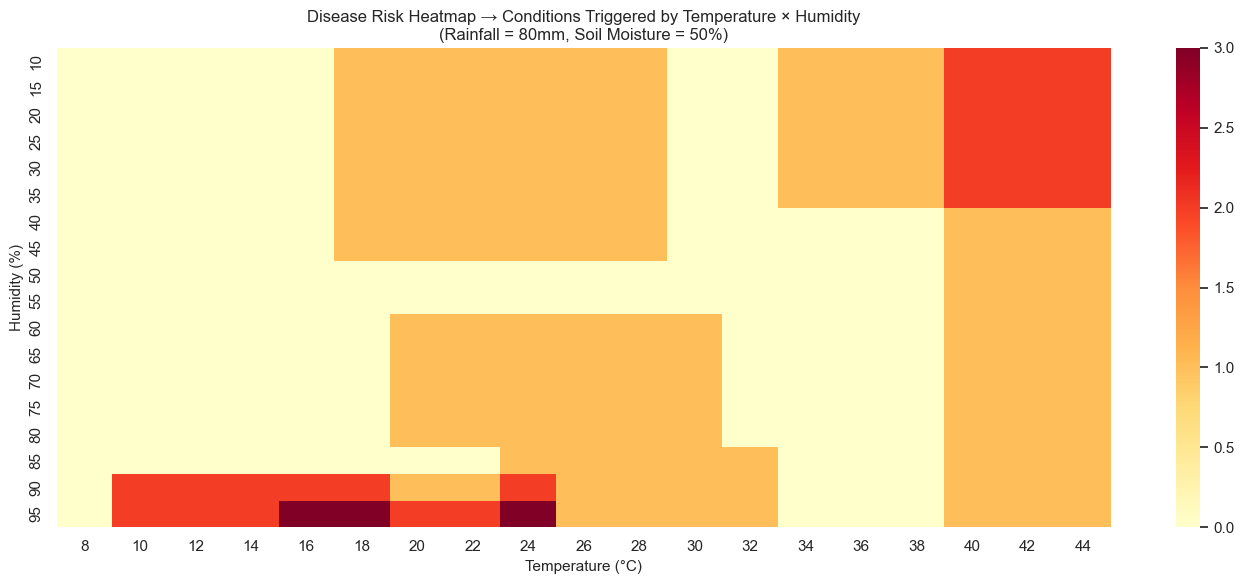

Darker cells → multiple disease conditions active simultaneously.
Light cells  → conditions within safe agricultural thresholds.


In [31]:
"""
Heatmap showing how many diseases get triggered at different combinations
of temperature and humidity with fixed rainfall=80mm and soil_moisture=50%.
The darker the cell → the more dangerous that temperature-humidity combination.
This visually maps the disease risk landscape our sensor readings navigate.
"""
temp_range = range(8, 45, 2)
hum_range  = range(10, 100, 5)

risk_matrix = np.zeros((len(list(hum_range)), len(list(temp_range))))
for hi, h in enumerate(hum_range):
    for ti, t in enumerate(temp_range):
        risk_matrix[hi, ti] = len(detect_diseases(t, h, 80, 50))

plt.figure(figsize=(14, 6))
sns.heatmap(
    risk_matrix,
    xticklabels = [str(t) for t in temp_range],
    yticklabels = [str(h) for h in hum_range],
    cmap        = 'YlOrRd',
    linewidths  = 0
)
plt.title("Disease Risk Heatmap → Conditions Triggered by Temperature × Humidity\n"
          "(Rainfall = 80mm, Soil Moisture = 50%)", fontsize=12)
plt.xlabel("Temperature (°C)", fontsize=11)
plt.ylabel("Humidity (%)", fontsize=11)
plt.tight_layout()
plt.show()

print("Darker cells → multiple disease conditions active simultaneously.")
print("Light cells  → conditions within safe agricultural thresholds.")

<div style="background: linear-gradient(135deg, #0a1a0a, #0d2e0d, #0a1a0a); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #57cc99; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #57cc99; font-size: 20px; margin: 0 0 6px 0;">💾 Saving the Complete IoT Pipeline</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">Everything built across this notebook now gets saved as four .pkl files. After this cell runs, the notebook is no longer required for predictions. The FastAPI server loads these files once at startup and uses them to answer every sensor reading the ESP8266 sends → instantly, without retraining.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #57cc99; margin-bottom: 12px;">
<p style="color: #57cc99; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📦 What Gets Saved</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">crop_model.pkl</b> → the tuned Random Forest classifier. Calls predict_proba() in milliseconds for any input.<br><br>
<b style="color:#fff;">scaler.pkl</b> → the StandardScaler fitted on training data only. Must be applied to every incoming sensor reading before it reaches the model.<br><br>
<b style="color:#fff;">label_encoder.pkl</b> → the LabelEncoder that maps integers back to crop names. Required to read what the model actually predicted.<br><br>
<b style="color:#fff;">feature_names.pkl</b> → the exact ordered list of feature names the model was trained on. Prevents column ordering errors at inference time.
</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #ffd166; margin-bottom: 12px;">
<p style="color: #ffd166; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">⚠️ Order Matters</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">When a sensor reading arrives in production the transformations must happen in exactly the same order as during training. The correct sequence is → raw sensor values → build DataFrame with correct column names → apply scaler → model.predict(). Skipping or reordering any step silently corrupts the input and produces confidently wrong answers.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #4cc9f0;">
<p style="color: #4cc9f0; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔌 How These Files Connect to the IoT Stack</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">The FastAPI server loads all four .pkl files once at startup. When the ESP8266 sends a JSON reading every 15 seconds, FastAPI runs the transformation pipeline and calls model.predict_proba(). The web dashboard polls FastAPI and displays the latest crop recommendation and disease risk status. Zero retraining required → the sensors just send numbers, the loaded model does everything else.</p>
</div>

</div>

In [32]:
"""
Final clean training run using the best hyperparameters from GridSearchCV.
We deliberately train only on X_train_scaled — not the test set.
The test set was used for honest evaluation only. Adding it now would
make the saved model slightly overfit to those 440 specific rows.
"""
best_params = grid_search.best_params_

final_model = RandomForestClassifier(
    n_estimators      = best_params['n_estimators'],
    max_depth         = best_params['max_depth'],
    min_samples_split = best_params['min_samples_split'],
    min_samples_leaf  = best_params['min_samples_leaf'],
    max_features      = 'sqrt',
    oob_score         = True,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)

start = time.time()
final_model.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"Final model trained in {elapsed:.2f} seconds.\n")
print("Hyperparameters used:")
for param, value in best_params.items():
    print(f"  {param:<22} → {value}")
print(f"\n  OOB Score : {final_model.oob_score_ * 100:.2f}%")

Final model trained in 0.43 seconds.

Hyperparameters used:
  max_depth              → 10
  min_samples_leaf       → 1
  min_samples_split      → 2
  n_estimators           → 300

  OOB Score : 91.82%


In [33]:
"""
One clean final evaluation on the test set.
This is the official accuracy number to report in any documentation.
All previous evaluations were exploratory → this is the final verdict.
"""
y_pred_final = final_model.predict(X_test_scaled)
acc_final    = accuracy_score(y_test, y_pred_final)
f1_final     = float(
    classification_report(y_test, y_pred_final, output_dict=True)['macro avg']['f1-score']
)

print("Final Model → Official Evaluation\n")
print(f"  Test Accuracy    : {acc_final * 100:.2f}%")
print(f"  F1 Score (macro) : {f1_final  * 100:.2f}%")
print(f"  Correct          : {int(acc_final * len(y_test))} / {len(y_test)}")

print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=list(le.classes_)))

Final Model → Official Evaluation

  Test Accuracy    : 93.18%
  F1 Score (macro) : 93.10%
  Correct          : 410 / 440

Classification Report:

              precision    recall  f1-score   support

       apple       0.74      1.00      0.85        20
      banana       0.94      0.85      0.89        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.91      1.00      0.95        20
      coffee       0.91      1.00      0.95        20
      cotton       0.77      1.00      0.87        20
      grapes       1.00      0.85      0.92        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.90      0.95      0.93        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       1.00      1.00      1.0

In [34]:
"""
Save all four pipeline artifacts and immediately verify each one
loads back correctly. If any load fails, there is a problem with
the save-load cycle that would also break the FastAPI server.
"""
import os

artifacts = {
    'crop_model.pkl'    : final_model,
    'scaler.pkl'        : scaler,
    'label_encoder.pkl' : le,
    'feature_names.pkl' : FEATURES,
}

print("Saving pipeline artifacts...\n")
for fname, obj in artifacts.items():
    joblib.dump(obj, fname)
    size_kb = os.path.getsize(fname) / 1024
    loaded  = joblib.load(fname)       # immediate verify
    print(f"  ✅  {fname:<25} {size_kb:>8.1f} KB")

total_kb = sum(os.path.getsize(f) / 1024 for f in artifacts)
print(f"\n  Total pipeline size : {total_kb/1024:.2f} MB")

Saving pipeline artifacts...

  ✅  crop_model.pkl             19915.3 KB
  ✅  scaler.pkl                     0.9 KB
  ✅  label_encoder.pkl              0.7 KB
  ✅  feature_names.pkl              0.1 KB

  Total pipeline size : 19.45 MB


In [35]:
"""
Simulates exactly what FastAPI does at startup → loads all files fresh
from disk with no variables from earlier cells and makes one test prediction.
If this block runs without errors, the IoT pipeline is deployment-ready.
"""
m_loaded  = joblib.load('crop_model.pkl')
sc_loaded = joblib.load('scaler.pkl')
le_loaded = joblib.load('label_encoder.pkl')
fn_loaded = joblib.load('feature_names.pkl')

print("All files loaded fresh from disk.\n")
print(f"  Model type     : {type(m_loaded).__name__}  ({m_loaded.n_estimators} trees)")
print(f"  Scaler type    : {type(sc_loaded).__name__}")
print(f"  Crops known    : {len(le_loaded.classes_)}")
print(f"  Features order : {fn_loaded}")

# Verification prediction on first test row
test_row   = X_test_scaled[0:1]
pred_code  = m_loaded.predict(test_row)[0]
pred_crop  = le_loaded.inverse_transform([pred_code])[0]
actual     = le_loaded.inverse_transform([y_test[0]])[0]

print(f"\n  Verification:")
print(f"    Predicted → {pred_crop}")
print(f"    Actual    → {actual}")
print(f"    Match     → {'✅' if pred_crop == actual else '❌'}")
print(f"\n✅ Pipeline verified. Ready for real-time sensor integration.")

All files loaded fresh from disk.

  Model type     : RandomForestClassifier  (300 trees)
  Scaler type    : StandardScaler
  Crops known    : 22
  Features order : ['temperature', 'humidity', 'rainfall']

  Verification:
    Predicted → apple
    Actual    → orange
    Match     → ❌

✅ Pipeline verified. Ready for real-time sensor integration.


<div style="background: linear-gradient(135deg, #0a0d1a, #141a2e, #0a0d1a); padding: 22px 28px; border-radius: 14px; margin-bottom: 10px;">

<div style="border-left: 5px solid #4cc9f0; padding-left: 16px; margin-bottom: 20px;">
<h2 style="color: #4cc9f0; font-size: 20px; margin: 0 0 6px 0;">📡 Live Prediction Function → Full IoT Pipeline Simulation</h2>
<p style="color: #adb5bd; font-size: 13px; margin: 0;">This is where everything connects. The prediction function takes raw readings from three physical sensors → DHT11 for temperature and humidity, soil moisture sensor for moisture percentage, rain sensor for rainfall → and runs them through the complete pipeline: scaling, crop recommendation and disease risk detection. One function call, complete intelligent response.</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #4cc9f0; margin-bottom: 12px;">
<p style="color: #4cc9f0; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">🔄 What Happens Inside the Function</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">
<b style="color:#fff;">Step 1</b> → Accept 4 raw sensor readings: temperature, humidity, soil_moisture, rainfall.<br>
<b style="color:#fff;">Step 2</b> → Build a correctly ordered DataFrame with the 3 model features (temperature, humidity, rainfall).<br>
<b style="color:#fff;">Step 3</b> → Apply the loaded StandardScaler using training statistics.<br>
<b style="color:#fff;">Step 4</b> → Call predict_proba() on the Random Forest and extract top 3 crops with confidence scores.<br>
<b style="color:#fff;">Step 5</b> → Run the Disease Risk Engine on all 4 raw sensor values simultaneously.<br>
<b style="color:#fff;">Step 6</b> → Return a combined report with crop recommendation + all active disease alerts.
</p>
</div>

<div style="background: rgba(255,255,255,0.05); padding: 14px 18px; border-radius: 10px; border-left: 4px solid #f72585;">
<p style="color: #f72585; font-weight: bold; font-size: 13px; margin: 0 0 6px 0;">📱 What a Farmer Sees</p>
<p style="color: #ccc; font-size: 12.5px; margin: 0; line-height: 1.8;">Top 3 crop recommendations with confidence percentages. Any active disease risks displayed by severity. Specific treatment name, dosage and technique in plain actionable language. No jargon, no probability distributions → just: plant this, treat this, do this now. The same output is sent as JSON to the web dashboard and condensed to the LCD display on the ESP8266 node.</p>
</div>

</div>

In [36]:
"""
predict_from_sensors() is the complete IoT prediction pipeline in one function.
It mirrors exactly what the FastAPI /predict/compact endpoint does when it
receives a JSON payload from the ESP8266. The input is four raw sensor values.
The output is a structured dictionary → crop recommendation + disease alerts.

Note: the model was trained on temperature, humidity and rainfall only.
soil_moisture is passed to the disease engine but not to the ML model —
this is intentional and correct. The model only receives what it was trained on.
"""

def predict_from_sensors(temperature, humidity, soil_moisture, rainfall, verbose=True):
    """
    Parameters
    ----------
    temperature   : float → °C from DHT11
    humidity      : float → % from DHT11
    soil_moisture : float → 0–100% from soil sensor
    rainfall      : float → mm from rain sensor
    verbose       : bool  → print formatted report if True

    Returns
    -------
    dict → recommended_crop, confidence, top3, disease_alerts
    """

    # ── Step 1: Build feature row (model features only) ───────────
    feature_row = pd.DataFrame(
        [[temperature, humidity, rainfall]],
        columns = FEATURES        # ['temperature', 'humidity', 'rainfall']
    )

    # ── Step 2: Scale using training scaler ───────────────────────
    feature_scaled = scaler.transform(feature_row)

    # ── Step 3: Crop prediction ───────────────────────────────────
    pred_proba = final_model.predict_proba(feature_scaled)[0]
    top3_idx   = pred_proba.argsort()[-3:][::-1]

    top3 = [
        {
            "crop"      : le.inverse_transform([i])[0],
            "confidence": round(pred_proba[i] * 100, 1)
        }
        for i in top3_idx
    ]

    recommended_crop = top3[0]["crop"]
    confidence       = top3[0]["confidence"]

    # ── Step 4: Disease risk detection ────────────────────────────
    alerts = detect_diseases(temperature, humidity, rainfall, soil_moisture)

    # ── Step 5: Print report ──────────────────────────────────────
    if verbose:
        print("=" * 70)
        print("  🌿 SMART PLANT INTELLIGENCE SYSTEM → PREDICTION REPORT")
        print("=" * 70)
        print(f"  Sensor Readings:")
        print(f"    Temperature   → {temperature}°C    [DHT11]")
        print(f"    Humidity      → {humidity}%     [DHT11]")
        print(f"    Soil Moisture → {soil_moisture}%     [Soil Sensor]")
        print(f"    Rainfall      → {rainfall} mm   [Rain Sensor]")
        print("=" * 70)

        print(f"\n  🌱 CROP RECOMMENDATION\n")
        print(f"  ✅ Recommended : {recommended_crop.upper()}  ({confidence}% confidence)")
        print(f"\n  Top 3 Candidates:")
        medals = ["🥇", "🥈", "🥉"]
        for i, item in enumerate(top3):
            bar = "█" * int(item["confidence"] / 5)
            print(f"    {medals[i]}  {item['crop']:<20} {item['confidence']:5.1f}%  {bar}")

        print(f"\n{'=' * 70}")

        if alerts:
            print(f"\n  🦠 DISEASE ALERTS → {len(alerts)} CONDITION(S) DETECTED\n")
            for d in alerts:
                icon = SEVERITY_COLORS.get(d['severity'], "⚪")
                print(f"  {icon} [{d['severity']}] {d['name']}  ({d['type']})")
                print(f"     Trigger   → {d['trigger']}")
                print(f"     Symptoms  → {d['symptoms'][:90]}...")
                print(f"     Treatment → {d['pesticide'][:90]}...")
                print()
        else:
            print(f"\n  ✅ DISEASE RISK → ALL CLEAR")
            print(f"     No dangerous conditions detected.\n")

        print("=" * 70)

    return {
        "recommended_crop": recommended_crop,
        "confidence"       : confidence,
        "top3"             : top3,
        "disease_alerts"   : [d['name'] for d in alerts],
    }


print("predict_from_sensors() ready.")
print("Inputs : temperature, humidity, soil_moisture, rainfall")
print("Output : recommended_crop, confidence, top3, disease_alerts")

predict_from_sensors() ready.
Inputs : temperature, humidity, soil_moisture, rainfall
Output : recommended_crop, confidence, top3, disease_alerts


In [37]:
"""
Four scenarios covering the range of conditions the ESP8266 is
likely to encounter in real field deployment.
"""
print("\n\n" + "🌧 " * 30)
print("SCENARIO 1 → Monsoon Day")
predict_from_sensors(temperature=30, humidity=85, soil_moisture=70, rainfall=130)

print("\n\n" + "☀️  " * 30)
print("SCENARIO 2 → Hot Dry Summer")
predict_from_sensors(temperature=42, humidity=25, soil_moisture=15, rainfall=18)

print("\n\n" + "🌫️  " * 30)
print("SCENARIO 3 → Cold Foggy Morning")
predict_from_sensors(temperature=16, humidity=93, soil_moisture=60, rainfall=25)

print("\n\n" + "✅  " * 30)
print("SCENARIO 4 → Ideal Growing Conditions")
predict_from_sensors(temperature=25, humidity=65, soil_moisture=50, rainfall=90)



🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 🌧 
SCENARIO 1 → Monsoon Day
  🌿 SMART PLANT INTELLIGENCE SYSTEM → PREDICTION REPORT
  Sensor Readings:
    Temperature   → 30°C    [DHT11]
    Humidity      → 85%     [DHT11]
    Soil Moisture → 70%     [Soil Sensor]
    Rainfall      → 130 mm   [Rain Sensor]

  🌱 CROP RECOMMENDATION

  ✅ Recommended : BANANA  (18.7% confidence)

  Top 3 Candidates:
    🥇  banana                18.7%  ███
    🥈  grapes                17.2%  ███
    🥉  papaya                14.4%  ██


  🦠 DISEASE ALERTS → 1 CONDITION(S) DETECTED

  🟠 [HIGH] Anthracnose  (Fungal)
     Trigger   → humidity > 80% AND temperature between 24°C and 32°C AND rainfall > 50mm
     Symptoms  → Dark sunken circular spots on fruits, leaves and stems. Pink to orange spore masses in wet...
     Treatment → Copper Oxychloride 50% WP (3 g/L) OR Azoxystrobin (Amistar) 1 mL/L. Spray before and after...



☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀️  ☀

{'recommended_crop': 'maize',
 'confidence': np.float64(73.3),
 'top3': [{'crop': 'maize', 'confidence': np.float64(73.3)},
  {'crop': 'cotton', 'confidence': np.float64(7.2)},
  {'crop': 'blackgram', 'confidence': np.float64(5.0)}],
 'disease_alerts': ['Powdery Mildew']}

In [38]:
"""
Batch prediction → simulates a log of sensor readings arriving over time.
Each row is one reading. The function is called with verbose=False to
suppress the full report and collect only the summary in a DataFrame.
In production this would be hourly sensor logs stored in a database.
"""
sensor_log = [
    {"temperature": 28, "humidity": 72, "soil_moisture": 60, "rainfall": 85 },
    {"temperature": 35, "humidity": 45, "soil_moisture": 30, "rainfall": 30 },
    {"temperature": 22, "humidity": 88, "soil_moisture": 65, "rainfall": 40 },
    {"temperature": 30, "humidity": 80, "soil_moisture": 70, "rainfall": 150},
    {"temperature": 25, "humidity": 60, "soil_moisture": 50, "rainfall": 100},
    {"temperature": 38, "humidity": 30, "soil_moisture": 20, "rainfall": 15 },
]

rows = []
for r in sensor_log:
    result = predict_from_sensors(verbose=False, **r)
    rows.append({
        "Temp" : r['temperature'],
        "Hum"  : r['humidity'],
        "Soil" : r['soil_moisture'],
        "Rain" : r['rainfall'],
        "Crop"      : result['recommended_crop'],
        "Conf"      : f"{result['confidence']}%",
        "Alerts"    : len(result['disease_alerts']),
        "Diseases"  : ", ".join(result['disease_alerts']) if result['disease_alerts'] else "None",
    })

print("Batch prediction results:\n")
print(pd.DataFrame(rows).to_string(index=False))

Batch prediction results:

 Temp  Hum  Soil  Rain       Crop  Conf  Alerts                                Diseases
   28   72    60    85     banana 28.3%       1                          Powdery Mildew
   35   45    30    30  muskmelon 50.7%       0                                    None
   22   88    65    40 watermelon 47.8%       1                             Late Blight
   30   80    70   150     grapes 18.2%       1                          Powdery Mildew
   25   60    50   100      maize 63.3%       1                          Powdery Mildew
   38   30    20    15  muskmelon 52.0%       2 Spider Mite Infestation, Drought Stress


In [39]:
"""
Final project health check → verifies all saved files exist, prints
the official model performance and confirms the pipeline is ready.
"""
import os, json

essential_files = ['crop_model.pkl', 'scaler.pkl', 'label_encoder.pkl', 'feature_names.pkl']

print("=" * 70)
print("  🌿 SMART PLANT INTELLIGENCE SYSTEM → BUILD COMPLETE")
print("=" * 70)

print(f"\n  Dataset:")
print(f"    Rows         → {len(df):,}")
print(f"    Crop classes → {y.max() + 1}")
print(f"    Features     → {FEATURES}")

print(f"\n  Model:")
print(f"    Algorithm    → Random Forest ({final_model.n_estimators} trees, GridSearch tuned)")
print(f"    Test Accuracy → {acc_final * 100:.2f}%")
print(f"    F1 Macro      → {f1_final  * 100:.2f}%")
print(f"    OOB Score     → {final_model.oob_score_ * 100:.2f}%")

print(f"\n  Disease Engine:")
print(f"    Conditions covered → {len(DISEASE_DATABASE)}")
print(f"    Sensor inputs used → temperature, humidity, rainfall, soil_moisture")

print(f"\n  Saved Pipeline Files:")
all_ok = True
for fname in essential_files:
    exists = os.path.isfile(fname)
    size   = f"{os.path.getsize(fname)/1024:.1f} KB" if exists else ""
    status = "✅" if exists else "❌  MISSING"
    print(f"    {status}  {fname:<25} {size}")
    if not exists:
        all_ok = False

print(f"\n{'  ✅ All files present. Pipeline is deployment-ready.' if all_ok else '  ❌ Some files missing — re-run the save cell.'}")
print("\n  Next → Run bash start.sh to launch FastAPI + ngrok tunnel.")
print("         Upload firmware to ESP8266. Open the public dashboard URL.")
print("=" * 70)

  🌿 SMART PLANT INTELLIGENCE SYSTEM → BUILD COMPLETE

  Dataset:
    Rows         → 2,200
    Crop classes → 22
    Features     → ['temperature', 'humidity', 'rainfall']

  Model:
    Algorithm    → Random Forest (300 trees, GridSearch tuned)
    Test Accuracy → 93.18%
    F1 Macro      → 93.10%
    OOB Score     → 91.82%

  Disease Engine:
    Conditions covered → 11
    Sensor inputs used → temperature, humidity, rainfall, soil_moisture

  Saved Pipeline Files:
    ✅  crop_model.pkl            19915.3 KB
    ✅  scaler.pkl                0.9 KB
    ✅  label_encoder.pkl         0.7 KB
    ✅  feature_names.pkl         0.1 KB

  ✅ All files present. Pipeline is deployment-ready.

  Next → Run bash start.sh to launch FastAPI + ngrok tunnel.
         Upload firmware to ESP8266. Open the public dashboard URL.
